<a href="https://colab.research.google.com/github/pooja1991pardeshi/masters/blob/taxi-starter-eda/EDA_Assg_NYC_Taxi_Starter_ver3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **New York City Yellow Taxi Data**

## Objective
In this case study you will be learning exploratory data analysis (EDA) with the help of a dataset on yellow taxi rides in New York City. This will enable you to understand why EDA is an important step in the process of data science and machine learning.

## **Problem Statement**
As an analyst at an upcoming taxi operation in NYC, you are tasked to use the 2023 taxi trip data to uncover insights that could help optimise taxi operations. The goal is to analyse patterns in the data that can inform strategic decisions to improve service efficiency, maximise revenue, and enhance passenger experience.

## Tasks
You need to perform the following steps for successfully completing this assignment:
1. Data Loading
2. Data Cleaning
3. Exploratory Analysis: Bivariate and Multivariate
4. Creating Visualisations to Support the Analysis
5. Deriving Insights and Stating Conclusions

---

**NOTE:** The marks given along with headings and sub-headings are cumulative marks for those particular headings/sub-headings.<br>

The actual marks for each task are specified within the tasks themselves.

For example, marks given with heading *2* or sub-heading *2.1* are the cumulative marks, for your reference only. <br>

The marks you will receive for completing tasks are given with the tasks.

Suppose the marks for two tasks are: 3 marks for 2.1.1 and 2 marks for 3.2.2, or
* 2.1.1 [3 marks]
* 3.2.2 [2 marks]

then, you will earn 3 marks for completing task 2.1.1 and 2 marks for completing task 3.2.2.


---

## Data Understanding
The yellow taxi trip records include fields capturing pick-up and drop-off dates/times, pick-up and drop-off locations, trip distances, itemized fares, rate types, payment types, and driver-reported passenger counts.

The data is stored in Parquet format (*.parquet*). The dataset is from 2009 to 2024. However, for this assignment, we will only be using the data from 2023.

The data for each month is present in a different parquet file. You will get twelve files for each of the months in 2023.

The data was collected and provided to the NYC Taxi and Limousine Commission (TLC) by technology providers like vendors and taxi hailing apps. <br>

You can find the link to the TLC trip records page here: https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

THE ABOVE LINK IS JUST FOR REFERENCE - PLEASE DO NOT USE THE DATASET PROVIDED IN THE ABOVE WEBPAGE FOR SOLVING THE ASSIGNMENT.

**Trip Records**



|Field Name       |description |
|:----------------|:-----------|
| VendorID | A code indicating the TPEP provider that provided the record. <br> 1= Creative Mobile Technologies, LLC; <br> 2= VeriFone Inc. |
| tpep_pickup_datetime | The date and time when the meter was engaged.  |
| tpep_dropoff_datetime | The date and time when the meter was disengaged.   |
| Passenger_count | The number of passengers in the vehicle. <br> This is a driver-entered value. |
| Trip_distance | The elapsed trip distance in miles reported by the taximeter. |
| PULocationID | TLC Taxi Zone in which the taximeter was engaged |
| DOLocationID | TLC Taxi Zone in which the taximeter was disengaged |
|RateCodeID |The final rate code in effect at the end of the trip.<br> 1 = Standard rate <br> 2 = JFK <br> 3 = Newark <br>4 = Nassau or Westchester <br>5 = Negotiated fare <br>6 = Group ride |
|Store_and_fwd_flag |This flag indicates whether the trip record was held in vehicle memory before sending to the vendor, aka “store and forward,” because the vehicle did not have a connection to the server.  <br>Y= store and forward trip <br>N= not a store and forward trip |
|Payment_type| A numeric code signifying how the passenger paid for the trip. <br> 1 = Credit card <br>2 = Cash <br>3 = No charge <br>4 = Dispute <br>5 = Unknown <br>6 = Voided trip |
|Fare_amount| The time-and-distance fare calculated by the meter. <br>Extra Miscellaneous extras and surcharges.  Currently, this only includes the 0.50 and 1 USD rush hour and overnight charges. |
|MTA_tax |0.50 USD MTA tax that is automatically triggered based on the metered rate in use. |
|Improvement_surcharge | 0.30 USD improvement surcharge assessed trips at the flag drop. The improvement surcharge began being levied in 2015. |
|Tip_amount |Tip amount – This field is automatically populated for credit card tips. Cash tips are not included. |
| Tolls_amount | Total amount of all tolls paid in trip.  |
| total_amount | The total amount charged to passengers. Does not include cash tips. |
|Congestion_Surcharge |Total amount collected in trip for NYS congestion surcharge. |
| Airport_fee | 1.25 USD for pick up only at LaGuardia and John F. Kennedy Airports|

Although the amounts of extra charges and taxes applied are specified in the data dictionary, you will see that some cases have different values of these charges in the actual data.

**Taxi Zones**

Each of the trip records contains a field corresponding to the location of the pickup or drop-off of the trip, populated by numbers ranging from 1-263.

These numbers correspond to taxi zones, which may be downloaded as a table or map/shapefile and matched to the trip records using a join.

This is covered in more detail in later sections.

---

## **1** Data Preparation

<font color = red>[5 marks]</font> <br>

### Import Libraries

In [1]:
# Import warnings
import warnings
warnings.filterwarnings("ignore")



In [2]:
#t’s a quick check that I am running the correct Python environment before loading libraries and data. It doesn’t change the data — it’s setup/debugging only.
import sys
print(sys.executable)

/usr/bin/python3


In [3]:
#Restart session is needed after running below command
!pip install --force-reinstall -q numpy==1.26.4
!pip install -q pandas==2.2.2
!pip install -q matplotlib==3.10.0
!pip install -q seaborn==0.13.2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 77.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompati

In [4]:
#cross checking whether session was restarted or not
import numpy as np
print(f'Numpy version after restart: {np.__version__}')
assert np.__version__ == '1.26.4', f'Expected 1.26.4 but found {np.__version__}. Did you restart the runtime?'

Numpy version after restart: 1.26.4


In [5]:
# Import the libraries you will be using for analysis
import numpy as np

import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns
import os




In [21]:
#t checks that the notebook is running from the right project folder so your data files load correctly.
cwd = os.getcwd()
print(cwd)






/content


In [22]:
!ls

drive  sample_data


In [8]:
# Recommended versions
# numpy version: 1.26.4
# pandas version: 2.2.2
# matplotlib version: 3.10.0
# seaborn version: 0.13.2


# Check versions
print("numpy version:", np.__version__)
print("pandas version:", pd.__version__)
print("matplotlib version:", plt.matplotlib.__version__)
print("seaborn version:", sns.__version__)

numpy version: 1.26.4
pandas version: 2.2.2
matplotlib version: 3.10.0
seaborn version: 0.13.2


### **1.1** Load the dataset
<font color = red>[5 marks]</font> <br>

You will see twelve files, one for each month.

To read parquet files with Pandas, you have to follow a similar syntax as that for CSV files.

`df = pd.read_parquet('file.parquet')`

In [23]:
#mounting google drive to access my data
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [31]:
!ls drive/MyDrive/masters/EDA/taxi_datasets/trip_records/

2023-10.parquet  2023-1.parquet  2023-4.parquet  2023-7.parquet
2023-11.parquet  2023-2.parquet  2023-5.parquet  2023-8.parquet
2023-12.parquet  2023-3.parquet  2023-6.parquet  2023-9.parquet


In [20]:
!ls drive/MyDrive/masters/EDA/tax

EDA_Assg_NYC_Taxi_Starter_old.ipynb   requirements.txt
EDA_Assg_NYC_Taxi_Starter_ver1.ipynb  SETUP.md
EDA_Assg_NYC_Taxi_Starter_ver2.ipynb  taxi_datasets
EDA_Assg_NYC_Taxi_Starter_ver3.ipynb


In [32]:
# Try loading one file

df=pd.read_parquet('//content/drive/MyDrive/masters/EDA/taxi_datasets/trip_records/2023-1.parquet')
# df = pd.read_parquet('2023-1.parquet')


In [33]:
#t prints a quick summary of your DataFrame like datatypes, number of rows, etc.
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3041714 entries, 0 to 3066765
Data columns (total 19 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  airport_fee            floa

How many rows are there? Do you think handling such a large number of rows is computationally feasible when we have to combine the data for all twelve months into one?

ANS :From df.info() on one month’s file (e.g. January 2023), there are about 3.04 million rows (~3,041,714 trips).And, all 12 months combined (without sampling) would be roughly 38 million rows (~3.2 million per month on average).No,because One month already uses ~464+ MB of memory in pandas; 12 months could be several GB, which can slow or crash the kernel.

To handle this, we need to sample a fraction of data from each of the files. How to go about that? Think of a way to select only some portion of the data from each month's file that accurately represents the trends.

ANS :We should not sample the whole file at once. Instead, for each month’s file, so first we do Split trips by pickup date and pickup hour (from tpep_pickup_datetime). second, Randomly take a small fraction (e.g. 5%) from each date–hour group.And, the last Combine the samples from all 12 months into one dataset.

---

**1.1.1** <font color = red>[5 marks]</font> <br>
Figure out how to sample and combine the files.

**Note:** It is not mandatory to use the method specified above. While sampling, you only need to make sure that your sampled data represents the overall data of all the months accurately.

#### Sampling the Data
> One way is to take a small percentage of entries for pickup in every hour of a date. So, for all the days in a month, we can iterate through the hours and select 5% values randomly from those. Use `tpep_pickup_datetime` for this. Separate date and hour from the datetime values and then for each date, select some fraction of trips for each of the 24 hours.

To sample data, you can use the `sample()` method. Follow this syntax:

```Python
# sampled_data is an empty DF to keep appending sampled data of each hour
# hour_data is the DF of entries for an hour 'X' on a date 'Y'

sample = hour_data.sample(frac = 0.05, random_state = 42)
# sample 0.05 of the hour_data
# random_state is just a seed for sampling, you can define it yourself

sampled_data = pd.concat([sampled_data, sample]) # adding data for this hour to the DF
```

This *sampled_data* will contain 5% values selected at random from each hour.

Note that the code given above is only the part that will be used for sampling and not the complete code required for sampling and combining the data files.

Keep in mind that you sample by date AND hour, not just hour. (Why?)

ANS : Because , if you sample only by hour, all days are mixed together. Busy days dominate each hour, and day-level patterns (weekday vs weekend, holidays) get distorted.

Sampling by date and hour takes a fraction from each day at each hour, so daily and hourly trends (rush hour, quiet nights, weekends) stay more like the full dataset.



In [34]:
# Take a small percentage of entries from each hour of every date.
# Iterating through the monthly data:
#   read a month file -> day -> hour: append sampled data -> move to next hour -> move to next day after 24 hours -> move to next month file
# Create a single dataframe for the year combining all the monthly data

# Select the folder having data files

import os
# Configuration
data_dir = "//content/drive/MyDrive/masters/EDA/taxi_datasets/trip_records/"
frac = 0.05
random_state = 42

# Create a list of all the twelve files to read
file_list = sorted([f for f in os.listdir(data_dir) if f.endswith(".parquet")])
print("files:", len(file_list))
print(file_list)

# Select the folder having data files
# df = final sampled data for the year
df = pd.DataFrame()

# iterate through the list of files and sample one by one:
for file_name in file_list:
    try:
        # file path for the current file
        file_path = os.path.join(data_dir, file_name)
        # Reading the current file
        month_df = pd.read_parquet(file_path)
        print(f"Reading file: {file_name}")

        # Normalize column names and locate pickup datetime column
        month_df.columns = month_df.columns.str.strip()
        if "tpep_pickup_datetime" not in month_df.columns:
            raise KeyError(f"'tpep_pickup_datetime' not found. Columns: {month_df.columns.tolist()}")

        # Convert Datetime Column to Date and Hour (Converts the pickup datetime column into proper datetime format Because datetime operations require datetime datatype.)
        # Parse datetime + keep only 2023
        month_df["tpep_pickup_datetime"] = pd.to_datetime(month_df["tpep_pickup_datetime"], errors="coerce")
        month_df = month_df.dropna(subset=["tpep_pickup_datetime"])
        month_df = month_df[
            (month_df["tpep_pickup_datetime"] >= "2023-01-01")
            & (month_df["tpep_pickup_datetime"] < "2024-01-01")
        ]

        # Create date/hour columns used for sampling
        month_df["pickup_date"] = month_df["tpep_pickup_datetime"].dt.date
        month_df["pickup_hour"] = month_df["tpep_pickup_datetime"].dt.hour

        # We will store the sampled data for the current date in this df by appending the sampled data from each hour to this
        # After completing iteration through each date, we will append this data to the final dataframe.
        sampled_data = pd.DataFrame()

        # Loop through dates and then loop through every hour of each date
        # Loop through each date
        for date in month_df["pickup_date"].unique():
            date_df = month_df[month_df["pickup_date"] == date]

            # Iterate through each hour of the selected date
            for hour in range(24):
                hour_data = date_df[date_df["pickup_hour"] == hour]
                # Skip if no rows
                if len(hour_data) == 0:
                    continue

                # Sample 5% of the hourly data randomly
                sample = hour_data.sample(frac=frac, random_state=random_state)
                # add data of this hour to the dataframe
                sampled_data = pd.concat([sampled_data, sample], ignore_index=True)

        print(file_name, "rows before:", len(month_df), "rows after sample:", len(sampled_data))
        # Concatenate the sampled data of all the dates to a single dataframe
        # we initialised this empty DF earlier
        df = pd.concat([df, sampled_data], ignore_index=True)

    except Exception as e:
        print(f"Error reading file {file_name}: {e}")



files: 12
['2023-1.parquet', '2023-10.parquet', '2023-11.parquet', '2023-12.parquet', '2023-2.parquet', '2023-3.parquet', '2023-4.parquet', '2023-5.parquet', '2023-6.parquet', '2023-7.parquet', '2023-8.parquet', '2023-9.parquet']
Reading file: 2023-1.parquet
2023-1.parquet rows before: 3041676 rows after sample: 152086
Reading file: 2023-10.parquet
2023-10.parquet rows before: 3485181 rows after sample: 174255
Reading file: 2023-11.parquet
2023-11.parquet rows before: 3302856 rows after sample: 165133
Reading file: 2023-12.parquet
2023-12.parquet rows before: 3333916 rows after sample: 166709
Reading file: 2023-2.parquet
2023-2.parquet rows before: 3374075 rows after sample: 168696
Reading file: 2023-3.parquet
2023-3.parquet rows before: 3275790 rows after sample: 163786
Reading file: 2023-4.parquet
2023-4.parquet rows before: 2792894 rows after sample: 139641
Reading file: 2023-5.parquet
2023-5.parquet rows before: 2889180 rows after sample: 144458
Reading file: 2023-6.parquet
2023-6.

In [37]:
# Sample the data
# It is recommmended to not load all the files at once to avoid memory overload

In [36]:
df.describe(include='all')

# The sample has ~1.83M trips, mostly 1 passenger, short distances, vendor 2, weekdays, with a few data issues (negative trip duration, very long trips) to clean.

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,pickup_date,pickup_hour,Airport_fee
count,1.896399e+06,1896399,1896399,1.831525e+06,1.896399e+06,1.831525e+06,1831525,1.896399e+06,1.896399e+06,1.896399e+06,...,1.896399e+06,1.896399e+06,1.896399e+06,1.896399e+06,1.896399e+06,1.831525e+06,148482.000000,1896399,1.896399e+06,1.683043e+06
unique,NaN,NaN,NaN,NaN,NaN,NaN,2,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,365,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023-12-14,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,1820286,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7169,NaN,NaN
mean,1.733026e+00,2023-07-02 20:00:01.260952,2023-07-02 20:17:27.250126,1.369215e+00,3.858294e+00,1.634694e+00,NaN,1.652814e+02,1.640515e+02,1.163817e+00,...,4.952796e-01,3.547011e+00,5.965341e-01,9.989706e-01,2.898187e+01,2.307524e+00,0.109037,NaN,1.426504e+01,1.458850e-01
min,1.000000e+00,2023-01-01 00:00:57,2023-01-01 00:09:35,0.000000e+00,0.000000e+00,1.000000e+00,NaN,1.000000e+00,1.000000e+00,0.000000e+00,...,-5.000000e-01,0.000000e+00,0.000000e+00,-1.000000e+00,-5.750000e+00,-2.500000e+00,-1.250000,NaN,0.000000e+00,-1.750000e+00
25%,1.000000e+00,2023-04-02 16:10:10.500000,2023-04-02 16:27:45,1.000000e+00,1.050000e+00,1.000000e+00,NaN,1.320000e+02,1.140000e+02,1.000000e+00,...,5.000000e-01,1.000000e+00,0.000000e+00,1.000000e+00,1.596000e+01,2.500000e+00,0.000000,NaN,1.100000e+01,0.000000e+00
50%,2.000000e+00,2023-06-27 15:44:33,2023-06-27 16:01:17,1.000000e+00,1.790000e+00,1.000000e+00,NaN,1.620000e+02,1.620000e+02,1.000000e+00,...,5.000000e-01,2.850000e+00,0.000000e+00,1.000000e+00,2.100000e+01,2.500000e+00,0.000000,NaN,1.500000e+01,0.000000e+00
75%,2.000000e+00,2023-10-06 19:37:48,2023-10-06 19:53:42,1.000000e+00,3.400000e+00,1.000000e+00,NaN,2.340000e+02,2.340000e+02,1.000000e+00,...,5.000000e-01,4.420000e+00,0.000000e+00,1.000000e+00,3.094000e+01,2.500000e+00,0.000000,NaN,1.900000e+01,0.000000e+00
max,6.000000e+00,2023-12-31 23:57:51,2024-01-01 20:50:55,9.000000e+00,1.263605e+05,9.900000e+01,NaN,2.650000e+02,2.650000e+02,4.000000e+00,...,4.000000e+00,2.230800e+02,1.430000e+02,1.000000e+00,1.431675e+05,2.500000e+00,1.250000,NaN,2.300000e+01,1.750000e+00


After combining the data files into one DataFrame, convert the new DataFrame to a CSV or parquet file and store it to use directly.

Ideally, you can try keeping the total entries to around 250,000 to 300,000.

In [39]:
#size of the dataframe (rows, columns)
df.shape


(1896399, 22)

In [40]:
#check that sampling is balanced across hours
df["pickup_hour"].value_counts().sort_index()

#Most taxi pickups happen daytime and evening (roughly 7 AM–8 PM), with the busiest hour around 6 PM (hour 18) and the quietest around 4–5 AM.

,count
pickup_hour,
0,53678
1,36029
2,23769
3,15675
4,10637
5,11136
6,26327
7,51826
8,71815


In [41]:
## Check pickup date range and unique days
df["pickup_date"].nunique(), df["pickup_date"].min(), df["pickup_date"].max()


#The data covers all of 2023, from January 1st to December 31st.

(365, datetime.date(2023, 1, 1), datetime.date(2023, 12, 31))

In [42]:
# Store the df in csv/parquet
output_path = "//content/drive/MyDrive/masters/EDA/taxi_datasets/trip_records/sampled_taxi_2023.parquet"
df.to_parquet(output_path, index=False)
print("Saved:", output_path)
print("Shape:", df.shape)


Saved: //content/drive/MyDrive/masters/EDA/taxi_datasets/trip_records/sampled_taxi_2023.parquet
Shape: (1896399, 22)


In [44]:
# df.to_parquet('')
df = pd.read_parquet("//content/drive/MyDrive/masters/EDA/taxi_datasets/trip_records/sampled_taxi_2023.parquet")

In [ ]:
# Check number of rows and columns in the dataset
df.shape

(1896399, 22)

## **2** Data Cleaning
<font color = red>[30 marks]</font> <br>

Now we can load the new data directly.

In [61]:
# Load the new data file

df = pd.read_parquet("//content/drive/MyDrive/masters/EDA/taxi_datasets/trip_records/sampled_taxi_2023.parquet")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())


Shape: (1896399, 22)
Columns: ['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime', 'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'airport_fee', 'pickup_date', 'pickup_hour', 'Airport_fee']


In [62]:
# df.head() to check the first few rows of the dataset
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,pickup_date,pickup_hour,Airport_fee
0,2,2023-01-01 00:07:18,2023-01-01 00:23:15,1.0,7.74,1.0,N,138,256,2,...,0.5,0.00,0.0,1.0,41.15,0.0,1.25,2023-01-01,0,NaN
1,2,2023-01-01 00:16:41,2023-01-01 00:21:46,2.0,1.24,1.0,N,161,237,1,...,0.5,2.58,0.0,1.0,15.48,2.5,0.00,2023-01-01,0,NaN
2,2,2023-01-01 00:14:03,2023-01-01 00:24:36,3.0,1.44,1.0,N,237,141,2,...,0.5,0.00,0.0,1.0,16.40,2.5,0.00,2023-01-01,0,NaN
3,2,2023-01-01 00:24:30,2023-01-01 00:29:55,1.0,0.54,1.0,N,143,142,2,...,0.5,0.00,0.0,1.0,11.50,2.5,0.00,2023-01-01,0,NaN
4,2,2023-01-01 00:43:00,2023-01-01 01:01:00,NaN,19.24,NaN,None,66,107,0,...,0.5,5.93,0.0,1.0,35.57,NaN,NaN,2023-01-01,0,NaN


In [63]:
# df.info() to check the data types of the columns
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1896399 entries, 0 to 1896398
Data columns (total 22 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   VendorID               int64         
 1   tpep_pickup_datetime   datetime64[us]
 2   tpep_dropoff_datetime  datetime64[us]
 3   passenger_count        float64       
 4   trip_distance          float64       
 5   RatecodeID             float64       
 6   store_and_fwd_flag     object        
 7   PULocationID           int64         
 8   DOLocationID           int64         
 9   payment_type           int64         
 10  fare_amount            float64       
 11  extra                  float64       
 12  mta_tax                float64       
 13  tip_amount             float64       
 14  tolls_amount           float64       
 15  improvement_surcharge  float64       
 16  total_amount           float64       
 17  congestion_surcharge   float64       
 18  airport_fee           

#### **2.1** Fixing Columns
<font color = red>[10 marks]</font> <br>

Fix/drop any columns as you seem necessary in the below sections

**2.1.1** <font color = red>[2 marks]</font> <br>

Fix the index and drop unnecessary columns

In [64]:
# Fix the index and drop any columns that are not needed

df = df.reset_index(drop=True)
df.columns = df.columns.str.strip()
df = df.drop_duplicates()

df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"])
df["tpep_dropoff_datetime"] = pd.to_datetime(df["tpep_dropoff_datetime"])
df["pickup_date"] = df["tpep_pickup_datetime"].dt.date
df["pickup_hour"] = df["tpep_pickup_datetime"].dt.hour

df.shape



(1896399, 22)

**2.1.2** <font color = red>[3 marks]</font> <br>
There are two airport fee columns. This is possibly an error in naming columns. Let's see whether these can be combined into a single column.

In [65]:

# Combine the two airport fee columns
df["airport_fee_combined"] = df["airport_fee"].fillna(0) + df["Airport_fee"].fillna(0)

# Drop the two original columns after combining
df = df.drop(columns=["airport_fee", "Airport_fee"])
df = df.rename(columns={"airport_fee_combined": "airport_fee"})

# Check result
df[["airport_fee"]].head()

,airport_fee
0,1.25
1,0.00
2,0.00
3,0.00
4,0.00


In [66]:
# Check result
df["airport_fee"].unique()

array([ 1.25,  0.  , -1.25,  1.75, -1.75,  1.  ])

**2.1.3** <font color = red>[5 marks]</font> <br>
Fix columns with negative (monetary) values

In [68]:
# check where values of fare amount are negative
neg_fare = df[df["fare_amount"] < 0]
print("Negative fare rows:", len(neg_fare))
neg_fare[["fare_amount", "RatecodeID", "payment_type", "total_amount"]].head()



Negative fare rows: 0


,fare_amount,RatecodeID,payment_type,total_amount


Did you notice something different in the `RatecodeID` column for above records?

Ans :No negative fare rows showed up, so there was no RatecodeID pattern to check in those records.

In [69]:
# Analyse RatecodeID for the negative fare amounts
neg_fare["RatecodeID"].value_counts()


,count
RatecodeID,


In [70]:
# Find which columns have negative values
money_cols = ["fare_amount", "extra", "mta_tax", "tip_amount", "tolls_amount",
              "improvement_surcharge", "total_amount", "congestion_surcharge", "airport_fee"]
(df[money_cols] < 0).sum()



,0
fare_amount,0
extra,3
mta_tax,73
tip_amount,0
tolls_amount,0
improvement_surcharge,78
total_amount,78
congestion_surcharge,56
airport_fee,15


In [71]:
# fix these negative values
for col in money_cols:
    df[col] = df[col].clip(lower=0)
(df[money_cols] < 0).sum()


,0
fare_amount,0
extra,0
mta_tax,0
tip_amount,0
tolls_amount,0
improvement_surcharge,0
total_amount,0
congestion_surcharge,0
airport_fee,0


### **2.2** Handling Missing Values
<font color = red>[10 marks]</font> <br>

**2.2.1**  <font color = red>[2 marks]</font> <br>
Find the proportion of missing values in each column




In [72]:
# Find the proportion of missing values in each column
missing_prop = df.isna().mean().sort_values(ascending=False)
missing_prop = (missing_prop * 100).round(2)  # in percentage
missing_prop[missing_prop > 0]


,0
passenger_count,3.42
RatecodeID,3.42
store_and_fwd_flag,3.42
congestion_surcharge,3.42


**2.2.2**  <font color = red>[3 marks]</font> <br>
Handling missing values in `passenger_count`

In [73]:
# Display the rows with null values
df[df["passenger_count"].isna()].head()

# Impute NaN values in 'passenger_count'
#We use median for passenger_count because it is a numeric column with possible outliers (e.g., very high passenger counts), and the median gives a typical value without being pulled by extreme values.
df["passenger_count"] = df["passenger_count"].fillna(df["passenger_count"].median())

df["passenger_count"].isna().sum()



0

In [74]:
# To check if the passenger_count is replaced with the median
df.describe()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,pickup_hour,airport_fee
count,1.896399e+06,1896399,1896399,1.896399e+06,1.896399e+06,1.831525e+06,1.896399e+06,1.896399e+06,1.896399e+06,1.896399e+06,1.896399e+06,1.896399e+06,1.896399e+06,1.896399e+06,1.896399e+06,1.896399e+06,1.831525e+06,1.896399e+06,1.896399e+06
mean,1.733026e+00,2023-07-02 20:00:01.260952,2023-07-02 20:17:27.250126,1.356585e+00,3.858294e+00,1.634694e+00,1.652814e+02,1.640515e+02,1.163817e+00,1.991936e+01,1.588020e+00,4.952989e-01,3.547011e+00,5.965341e-01,9.990118e-01,2.898202e+01,2.307600e+00,1.426504e+01,1.380221e-01
min,1.000000e+00,2023-01-01 00:00:57,2023-01-01 00:09:35,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.000000e+00,2023-04-02 16:10:10.500000,2023-04-02 16:27:45,1.000000e+00,1.050000e+00,1.000000e+00,1.320000e+02,1.140000e+02,1.000000e+00,9.300000e+00,0.000000e+00,5.000000e-01,1.000000e+00,0.000000e+00,1.000000e+00,1.596000e+01,2.500000e+00,1.100000e+01,0.000000e+00
50%,2.000000e+00,2023-06-27 15:44:33,2023-06-27 16:01:17,1.000000e+00,1.790000e+00,1.000000e+00,1.620000e+02,1.620000e+02,1.000000e+00,1.350000e+01,1.000000e+00,5.000000e-01,2.850000e+00,0.000000e+00,1.000000e+00,2.100000e+01,2.500000e+00,1.500000e+01,0.000000e+00
75%,2.000000e+00,2023-10-06 19:37:48,2023-10-06 19:53:42,1.000000e+00,3.400000e+00,1.000000e+00,2.340000e+02,2.340000e+02,1.000000e+00,2.190000e+01,2.500000e+00,5.000000e-01,4.420000e+00,0.000000e+00,1.000000e+00,3.094000e+01,2.500000e+00,1.900000e+01,0.000000e+00
max,6.000000e+00,2023-12-31 23:57:51,2024-01-01 20:50:55,9.000000e+00,1.263605e+05,9.900000e+01,2.650000e+02,2.650000e+02,4.000000e+00,1.431635e+05,2.080000e+01,4.000000e+00,2.230800e+02,1.430000e+02,1.000000e+00,1.431675e+05,2.500000e+00,2.300000e+01,1.750000e+00
std,4.476402e-01,NaN,NaN,8.799161e-01,1.294086e+02,7.393917e+00,6.400039e+01,6.980208e+01,5.081385e-01,1.055371e+02,1.829197e+00,4.855677e-02,4.054883e+00,2.187878e+00,2.907216e-02,1.064162e+02,6.663189e-01,5.807379e+00,4.575629e-01


In [75]:
# Check for zero passenger_count
(df["passenger_count"] == 0).sum()

29681

Did you find zeroes in passenger_count? Handle these.

Ans :Yes — some trips have passenger_count = 0, which is invalid (every trip should have at least 1 passenger). I replaced 0 with 1, since 1 is the most common passenger count in the data.



**2.2.3**  <font color = red>[2 marks]</font> <br>
Handle missing values in `RatecodeID`

In [76]:

# Fix missing values in 'RatecodeID'
df[df["RatecodeID"].isna()].head()
#We use mode because RatecodeID is a category code, not a true number — the most common code (usually 1 = Standard rate) is the safest way to fill missing values.
df["RatecodeID"] = df["RatecodeID"].fillna(df["RatecodeID"].mode()[0])

df["RatecodeID"].isna().sum()


0

**2.2.4**  <font color = red>[3 marks]</font> <br>
Impute NaN in `congestion_surcharge`

In [77]:

# handle null values in congestion_surcharge
df[df["congestion_surcharge"].isna()].head()
#We fill missing congestion_surcharge with 0 because a missing value usually means the congestion charge was not applied to that trip.
df["congestion_surcharge"] = df["congestion_surcharge"].fillna(0)

df["congestion_surcharge"].isna().sum()



0

Are there missing values in other columns? Did you find NaN values in some other set of columns? Handle those missing values below.

Ans : Yes, After fixing the other columns, only store_and_fwd_flag still had missing values (~3.42%). I filled them with N (the mode), since most trips are not store-and-forward. Now there are no missing values left in the dataset.

In [78]:
# Handle any remaining missing values
(df.isna().sum()[df.isna().sum() > 0])

# store_and_fwd_flag (remaining column with NaN)
#After fixing other columns, store_and_fwd_flag still had NaNs, so we filled them with the mode (N = not store-and-forward), since it is a category flag.
df["store_and_fwd_flag"] = df["store_and_fwd_flag"].fillna(df["store_and_fwd_flag"].mode()[0])

# verify no missing values left
(df.isna().mean() * 100).round(2)




,0
VendorID,0.0
tpep_pickup_datetime,0.0
tpep_dropoff_datetime,0.0
passenger_count,0.0
trip_distance,0.0
RatecodeID,0.0
store_and_fwd_flag,0.0
PULocationID,0.0
DOLocationID,0.0
payment_type,0.0


### **2.3** Handling Outliers
<font color = red>[10 marks]</font> <br>

Before we start fixing outliers, let's perform outlier analysis.

In [79]:
# Describe the data and check if there are any potential outliers present
cols = ["passenger_count", "trip_distance", "fare_amount", "total_amount", "tip_amount"]
df[cols].describe()



,passenger_count,trip_distance,fare_amount,total_amount,tip_amount
count,1.896399e+06,1.896399e+06,1.896399e+06,1.896399e+06,1.896399e+06
mean,1.356585e+00,3.858294e+00,1.991936e+01,2.898202e+01,3.547011e+00
std,8.799161e-01,1.294086e+02,1.055371e+02,1.064162e+02,4.054883e+00
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.000000e+00,1.050000e+00,9.300000e+00,1.596000e+01,1.000000e+00
50%,1.000000e+00,1.790000e+00,1.350000e+01,2.100000e+01,2.850000e+00
75%,1.000000e+00,3.400000e+00,2.190000e+01,3.094000e+01,4.420000e+00
max,9.000000e+00,1.263605e+05,1.431635e+05,1.431675e+05,2.230800e+02


In [80]:
# Check for potential out of place values in various columns
#We use this code to quickly count unrealistic/error trips (invalid payment type, impossible distance/fare combinations, and extreme passenger counts) before removing or fixing them, so the cleaned dataset reflects normal NYC taxi behavior.print("payment_type = 0:", (df["payment_type"] == 0).sum())
print("trip_distance > 250:", (df["trip_distance"] > 250).sum())
print("trip_distance ~ 0 & fare > 300:", ((df["trip_distance"] < 0.1) & (df["fare_amount"] > 300)).sum())
print("distance=0 & fare=0 but different zones:",
      ((df["trip_distance"] == 0) & (df["fare_amount"] == 0) & (df["PULocationID"] != df["DOLocationID"])).sum())
print("passenger_count >= 7:", (df["passenger_count"] >= 7).sum())

trip_distance > 250: 46
trip_distance ~ 0 & fare > 300: 35
distance=0 & fare=0 but different zones: 63
passenger_count >= 7: 21


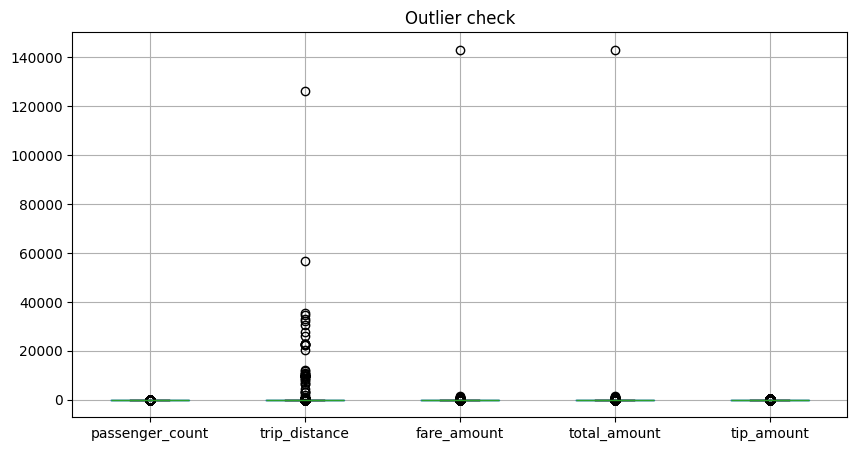

In [81]:
# I use a  boxplot quickly shows the spread and extreme values in each column — points far above the whiskers are likely outliers, so we can spot them visually before fixing the data.
df[cols].boxplot(figsize=(10, 5))
plt.title("Outlier check")
plt.show()

**2.3.1**  <font color = red>[10 marks]</font> <br>
Based on the above analysis, it seems that some of the outliers are present due to errors in registering the trips. Fix the outliers.

Some points you can look for:
- Entries where `trip_distance` is nearly 0 and `fare_amount` is more than 300
- Entries where `trip_distance` and `fare_amount` are 0 but the pickup and dropoff zones are different (both distance and fare should not be zero for different zones)
- Entries where `trip_distance` is more than 250  miles.
- Entries where `payment_type` is 0 (there is no payment_type 0 defined in the data dictionary)

These are just some suggestions. You can handle outliers in any way you wish, using the insights from above outlier analysis.

How will you fix each of these values? Which ones will you drop and which ones will you replace?

Ans : The boxplot showed some trips with crazy values — like huge distance or fare that don’t make sense. Those look like mistakes, so I deleted those rows. I didn’t try to fix them with fake numbers, because that would make the data wrong.

First, let us remove 7+ passenger counts as there are very less instances.

In [82]:
# remove passenger_count > 6
df = df[df["passenger_count"] <= 6]
df.shape


(1896378, 21)

In [83]:
# Continue with outlier handling
before = len(df)
df = df[df["payment_type"] != 0]
df = df[df["trip_distance"] <= 250]
df = df[~((df["trip_distance"] < 0.1) & (df["fare_amount"] > 300))]
df = df[~((df["trip_distance"] == 0) & (df["fare_amount"] == 0) & (df["PULocationID"] != df["DOLocationID"]))]

print("Rows removed:", before - len(df))
df.shape
#We drop these outlier rows because they represent invalid or impossible trips, not normal variation that can be corrected by replacement.



Rows removed: 64988


(1831390, 21)

In [84]:
# Do any columns need standardising?
df.dtypes


,0
VendorID,int64
tpep_pickup_datetime,datetime64[us]
tpep_dropoff_datetime,datetime64[us]
passenger_count,float64
trip_distance,float64
RatecodeID,float64
store_and_fwd_flag,object
PULocationID,int64
DOLocationID,int64
payment_type,int64


In [85]:
# standardise ID/count columns to integer type
#After cleaning, column names are already fine; we only standardise data types (convert ID/count fields from float to int) so analysis and plots are consistent.
for col in ["VendorID", "PULocationID", "DOLocationID", "payment_type", "passenger_count", "RatecodeID"]:
    df[col] = df[col].astype(int)
df.dtypes

,0
VendorID,int64
tpep_pickup_datetime,datetime64[us]
tpep_dropoff_datetime,datetime64[us]
passenger_count,int64
trip_distance,float64
RatecodeID,int64
store_and_fwd_flag,object
PULocationID,int64
DOLocationID,int64
payment_type,int64


## **3** Exploratory Data Analysis
<font color = red>[90 marks]</font> <br>

In [86]:
# To check the columns
df.columns.tolist()

['VendorID',
 'tpep_pickup_datetime',
 'tpep_dropoff_datetime',
 'passenger_count',
 'trip_distance',
 'RatecodeID',
 'store_and_fwd_flag',
 'PULocationID',
 'DOLocationID',
 'payment_type',
 'fare_amount',
 'extra',
 'mta_tax',
 'tip_amount',
 'tolls_amount',
 'improvement_surcharge',
 'total_amount',
 'congestion_surcharge',
 'pickup_date',
 'pickup_hour',
 'airport_fee']

#### **3.1** General EDA: Finding Patterns and Trends
<font color = red>[40 marks]</font> <br>

**3.1.1** <font color = red>[3 marks]</font> <br>
Categorise the varaibles into Numerical or Categorical.
* `VendorID`: Categorical
* `tpep_pickup_datetime`:Numerical
* `tpep_dropoff_datetime`:Numerical
* `passenger_count`:Numerical
* `trip_distance`:Numerical
* `RatecodeID`:Categorical
* `PULocationID`:Categorical
* `DOLocationID`:Categorical
* `payment_type`:Categorical
* `pickup_hour`:Numerical
* `trip_duration`:Numerical


The following monetary parameters belong in the same category, is it categorical or numerical?


* `fare_amount`:Numerical
* `extra`:Numerical
* `mta_tax`:Numerical
* `tip_amount`:Numerical
* `tolls_amount`:Numerical
* `improvement_surcharge`:Numerical
* `total_amount`:Numerical
* `congestion_surcharge`:Numerical
* `airport_fee`:Numerical

##### Temporal Analysis

**3.1.2** <font color = red>[5 marks]</font> <br>
Analyse the distribution of taxi pickups by hours, days of the week, and months.

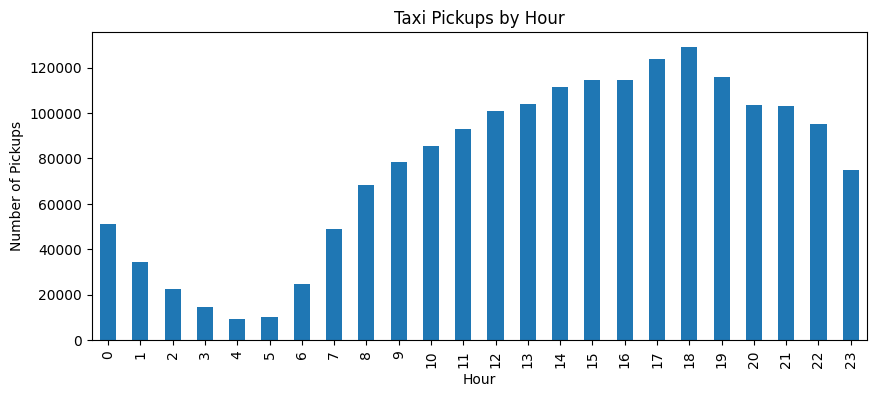

In [87]:
# Find and show the hourly trends in taxi pickups
hourly = df.groupby("pickup_hour").size()

plt.figure(figsize=(10, 4))
hourly.plot(kind="bar")
plt.title("Taxi Pickups by Hour")
plt.xlabel("Hour")
plt.ylabel("Number of Pickups")
plt.show()


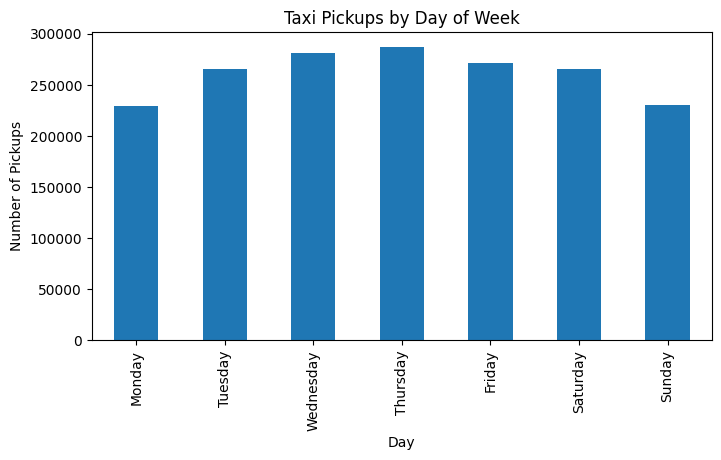

In [88]:
# Find and show the daily trends in taxi pickups (days of the week)
df["pickup_day"] = df["tpep_pickup_datetime"].dt.day_name()
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
daily = df.groupby("pickup_day").size().reindex(day_order)

plt.figure(figsize=(8, 4))
daily.plot(kind="bar")
plt.title("Taxi Pickups by Day of Week")
plt.xlabel("Day")
plt.ylabel("Number of Pickups")
plt.show()


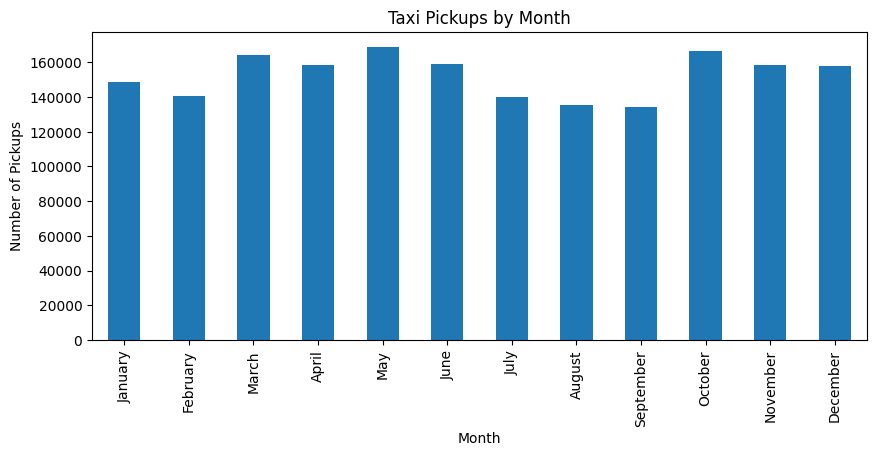

In [89]:
# Show the monthly trends in pickups
df["pickup_month"] = df["tpep_pickup_datetime"].dt.month_name()
month_order = ["January", "February", "March", "April", "May", "June",
               "July", "August", "September", "October", "November", "December"]
monthly = df.groupby("pickup_month").size().reindex(month_order)

plt.figure(figsize=(10, 4))
monthly.plot(kind="bar")
plt.title("Taxi Pickups by Month")
plt.xlabel("Month")
plt.ylabel("Number of Pickups")
plt.show()
#Pickups are usually lower late night, higher on weekdays/evenings, and vary by month/season.



##### Financial Analysis

Take a look at the financial parameters like `fare_amount`, `tip_amount`, `total_amount`, and also `trip_distance`. Do these contain zero/negative values?

Ans : After cleaning, there are no negative values; zeros exist — especially in tip_amount (no tip), and also in trip_distance, fare_amount, and total_amount.

In [90]:
# Analyse the above parameters
cols = ["fare_amount", "tip_amount", "total_amount", "trip_distance"]
df[cols].describe()
# check zero and negative values
for col in cols:
    print(col, "| zero:", (df[col] == 0).sum(), "| negative:", (df[col] < 0).sum())
#After cleaning, negative values should be 0; zero values can still exist (especially tip_amount for cash/no-tip trips).


fare_amount | zero: 575 | negative: 0
tip_amount | zero: 410234 | negative: 0
total_amount | zero: 329 | negative: 0
trip_distance | zero: 22928 | negative: 0


Do you think it is beneficial to create a copy DataFrame leaving out the zero values from these?

Ans :It is beneficial to create a separate copy without zero values for specific analyses (like fare per mile or average tips), but not for all EDA, because many zero values are valid or important to keep in the full dataset.

**3.1.3** <font color = red>[2 marks]</font> <br>
Filter out the zero values from the above columns.

**Note:** The distance might be 0 in cases where pickup and drop is in the same zone. Do you think it is suitable to drop such cases of zero distance?

In [91]:
# Create a df with non zero entries for the selected parameters.
df_nonzero = df[
    (df["fare_amount"] > 0) &
    (df["tip_amount"] > 0) &
    (df["total_amount"] > 0) &
    (df["trip_distance"] > 0)
].copy()

df_nonzero.shape
#It is not always suitable to drop all zero-distance trips, because pickup and dropoff in the same zone can be valid. So use df_nonzero mainly for financial/rate analysis, and keep the full df for general EDA.

(1412904, 23)

**3.1.4** <font color = red>[3 marks]</font> <br>
Analyse the monthly revenue (`total_amount`) trend

In [92]:
# Group data by month and analyse monthly revenue
df["pickup_month"] = df["tpep_pickup_datetime"].dt.to_period("M")
# Group by month and sum revenue

monthly_revenue = df.groupby("pickup_month")["total_amount"].sum()
monthly_revenue


,total_amount
pickup_month,
2023-01,4055113.78
2023-02,3834417.13
2023-03,4624721.17
2023-04,4540763.32
2023-05,4944775.70
2023-06,4654478.32
2023-07,4051763.81
2023-08,3948512.58
2023-09,4171703.09


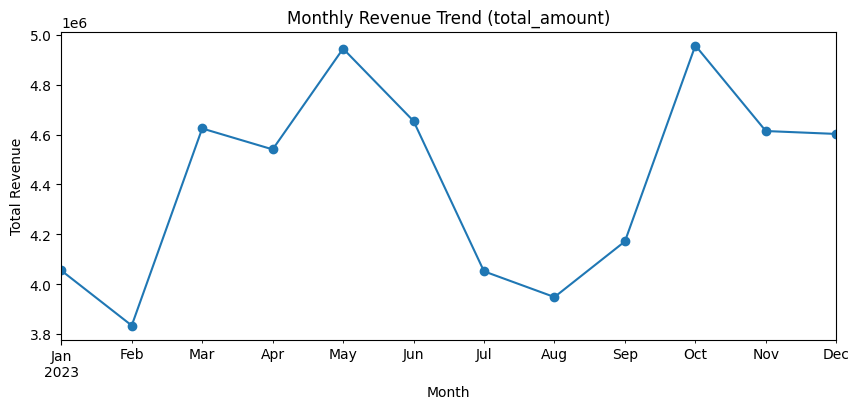

In [93]:
#Plotting the monthly revenue trend helps us understand seasonal patterns and revenue fluctuations.
#Revenue rises/falls across months due to seasonality, holidays, and changes in trip demand.
monthly_revenue.plot(kind="line", marker="o", figsize=(10, 4))
plt.title("Monthly Revenue Trend (total_amount)")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.show()

**3.1.5** <font color = red>[3 marks]</font> <br>
Show the proportion of each quarter of the year in the revenue

In [94]:
# Calculate proportion of each quarter
df["quarter"] = df["tpep_pickup_datetime"].dt.quarter
quarter_revenue = df.groupby("quarter")["total_amount"].sum()
quarter_prop = (quarter_revenue / quarter_revenue.sum() * 100).round(2)
quarter_prop


,total_amount
quarter,
1,23.61
2,26.68
3,22.97
4,26.74


**3.1.6** <font color = red>[3 marks]</font> <br>
Visualise the relationship between `trip_distance` and `fare_amount`. Also find the correlation value for these two.

**Hint:** You can leave out the trips with trip_distance = 0

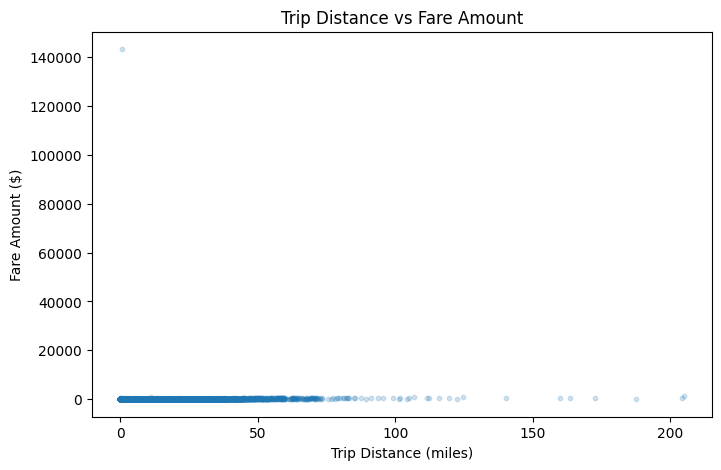

In [95]:
# Show how trip fare is affected by distance
temp = df[df["trip_distance"] > 0][["trip_distance", "fare_amount"]]

# correlation
temp["trip_distance"].corr(temp["fare_amount"])

# scatter plot
plt.figure(figsize=(8, 5))
plt.scatter(temp["trip_distance"], temp["fare_amount"], alpha=0.2, s=10)
plt.title("Trip Distance vs Fare Amount")
plt.xlabel("Trip Distance (miles)")
plt.ylabel("Fare Amount ($)")
plt.show()

# The plot shows Fare generally increases with distance (positive correlation), but very high fares at low distances are likely outliers/errors.



**3.1.7** <font color = red>[5 marks]</font> <br>
Find and visualise the correlation between:
1. `fare_amount` and trip duration (pickup time to dropoff time)
2. `fare_amount` and `passenger_count`
3. `tip_amount` and `trip_distance`

Correlation: 0.04472131080813717


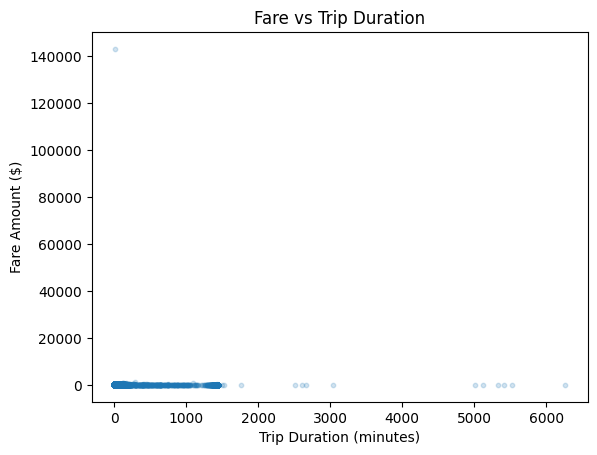

In [96]:
# Show relationship between fare and trip duration
df["trip_duration"] = (df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]).dt.total_seconds() / 60
temp = df[df["trip_duration"] > 0]
print("Correlation:", temp["fare_amount"].corr(temp["trip_duration"]))
plt.scatter(temp["trip_duration"], temp["fare_amount"], alpha=0.2, s=10)
plt.xlabel("Trip Duration (minutes)")
plt.ylabel("Fare Amount ($)")
plt.title("Fare vs Trip Duration")
plt.show()

# The plot shows that fare generally increases with trip duration, but there are some outliers with high fares at low durations.


Correlation: 0.007536991984687118


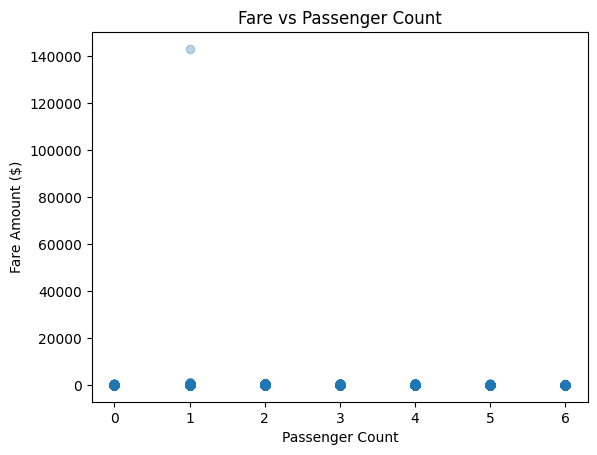

In [97]:
# Show relationship between fare and number of passengers
print("Correlation:", df["fare_amount"].corr(df["passenger_count"]))

# Scatter plot
plt.scatter(df["passenger_count"], df["fare_amount"], alpha=0.3)
plt.xlabel("Passenger Count")
plt.ylabel("Fare Amount ($)")
plt.title("Fare vs Passenger Count")
plt.show()

# The plot shows that fare generally increases with passenger count, but there are some outliers with high fares at low passenger counts.

Correlation: 0.5857091449320657


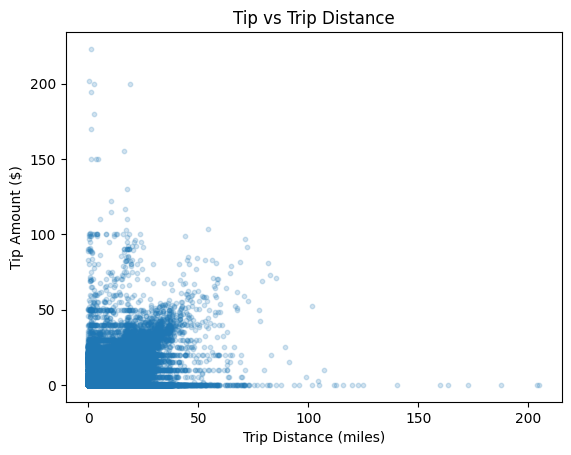

In [98]:
# Show relationship between tip and trip distance
temp = df[df["trip_distance"] > 0]
print("Correlation:", temp["tip_amount"].corr(temp["trip_distance"]))

# Scatter plot
plt.scatter(temp["trip_distance"], temp["tip_amount"], alpha=0.2, s=10)
plt.xlabel("Trip Distance (miles)")
plt.ylabel("Tip Amount ($)")
plt.title("Tip vs Trip Distance")
plt.show()

# The plot shows that tip amount generally increases with trip distance, but there are some outliers with high tips at low distances.

**3.1.8** <font color = red>[3 marks]</font> <br>
Analyse the distribution of different payment types (`payment_type`)

payment_type
1    1492300
2     316412
3       9006
4      13672
Name: count, dtype: int64
payment_type
1    81.48
2    17.28
3     0.49
4     0.75
Name: proportion, dtype: float64


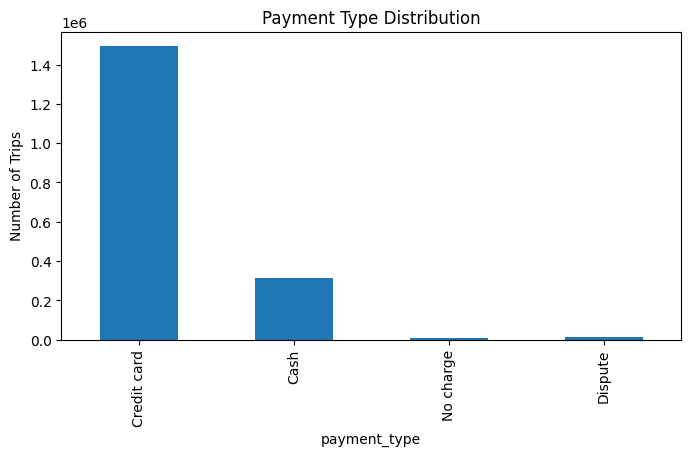

In [99]:
# Analyse the distribution of different payment types (payment_type).

payment_map = {1: "Credit card", 2: "Cash", 3: "No charge", 4: "Dispute", 5: "Unknown", 6: "Voided"}

payment_dist = df["payment_type"].value_counts().sort_index()
payment_pct = (df["payment_type"].value_counts(normalize=True) * 100).round(2).sort_index()

print(payment_dist)
print(payment_pct)

payment_dist.index = payment_dist.index.map(payment_map)
payment_dist.plot(kind="bar", figsize=(8, 4))
plt.title("Payment Type Distribution")
plt.ylabel("Number of Trips")
plt.show()

# The plot shows that most trips are paid by credit card, followed by cash.



- 1= Credit card
- 2= Cash
- 3= No charge
- 4= Dispute



##### Geographical Analysis

For this, you have to use the *taxi_zones.shp* file from the *taxi_zones* folder.

There would be multiple files inside the folder (such as *.shx, .sbx, .sbn* etc). You do not need to import/read any of the files other than the shapefile, *taxi_zones.shp*.

Do not change any folder structure - all the files need to be present inside the folder for it to work.

The folder structure should look like this:
```
Taxi Zones
|- taxi_zones.shp.xml
|- taxi_zones.prj
|- taxi_zones.sbn
|- taxi_zones.shp
|- taxi_zones.dbf
|- taxi_zones.shx
|- taxi_zones.sbx

 ```

 You only need to read the `taxi_zones.shp` file. The *shp* file will utilise the other files by itself.

We will use the *GeoPandas* library for geopgraphical analysis
```
import geopandas as gpd
```

More about geopandas and shapefiles: [About](https://geopandas.org/en/stable/about.html)


Reading the shapefile is very similar to *Pandas*. Use `gpd.read_file()` function to load the data (*taxi_zones.shp*) as a GeoDataFrame. Documentation: [Reading and Writing Files](https://geopandas.org/en/stable/docs/user_guide/io.html)

In [101]:
!pip install geopandas



**3.1.9** <font color = red>[2 marks]</font> <br>
Load the shapefile and display it.

In [113]:
# import geopandas as gpd
import geopandas as gpd


# Read the shapefile using geopandas
zones = "/content/drive/MyDrive/masters/EDA/taxi_datasets/taxi_zones/taxi_zones.shp"
taxi_zones= gpd.read_file(zones)
taxi_zones.head()

,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19..."
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343..."
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2..."
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20..."
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144..."


Now, if you look at the DataFrame created, you will see columns like: `OBJECTID`,`Shape_Leng`, `Shape_Area`, `zone`, `LocationID`, `borough`, `geometry`.
<br><br>

Now, the `locationID` here is also what we are using to mark pickup and drop zones in the trip records.

The geometric parameters like shape length, shape area and geometry are used to plot the zones on a map.

This can be easily done using the `plot()` method.

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 263 entries, 0 to 262
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   OBJECTID    263 non-null    int32   
 1   Shape_Leng  263 non-null    float64 
 2   Shape_Area  263 non-null    float64 
 3   zone        263 non-null    object  
 4   LocationID  263 non-null    int32   
 5   borough     263 non-null    object  
 6   geometry    263 non-null    geometry
dtypes: float64(2), geometry(1), int32(2), object(2)
memory usage: 12.5+ KB
None


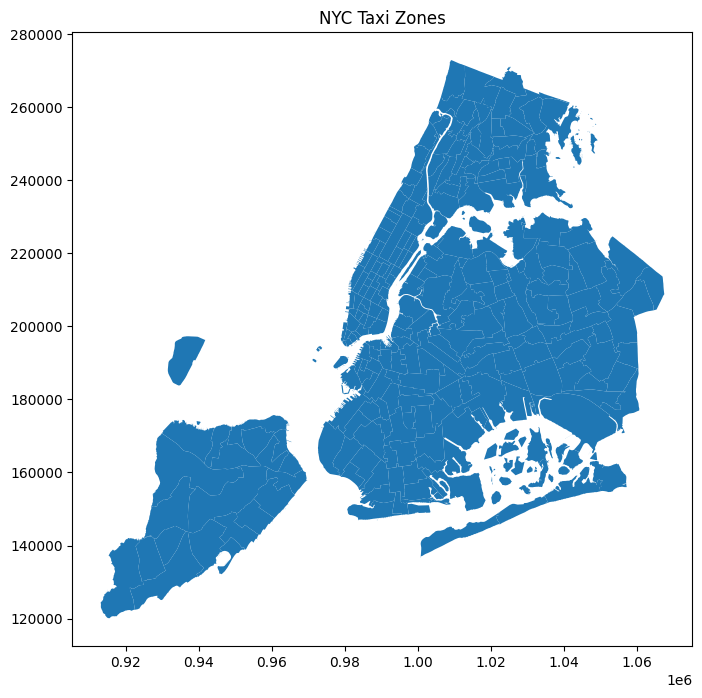

In [114]:
# print(zones.info())
print(taxi_zones.info())

# zones.plot()
taxi_zones.plot(figsize=(8, 8))
plt.title("NYC Taxi Zones")
plt.show()
# It is a zone boundary map of NYC, not trip routes — it shows where taxis can pick up/drop off, not how many trips happened yet.

Now, you have to merge the trip records and zones data using the location IDs.



**3.1.10** <font color = red>[3 marks]</font> <br>
Merge the zones data into trip data using the `locationID` and `PULocationID` columns.

In [115]:
# Merge zones and trip records using locationID and PULocationID
zones_with_trips = df.merge(
    taxi_zones[["LocationID", "zone", "borough", "geometry"]],
    left_on="PULocationID",
    right_on="LocationID",
    how="left"
)
zones_with_trips.head()



,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,...,pickup_hour,airport_fee,pickup_day,pickup_month,quarter,trip_duration,LocationID,zone,borough,geometry
0,2,2023-01-01 00:07:18,2023-01-01 00:23:15,1,7.74,1,N,138,256,2,...,0,1.25,Sunday,2023-01,1,15.950000,138.0,LaGuardia Airport,Queens,"MULTIPOLYGON (((1019904.219 225677.983, 102031..."
1,2,2023-01-01 00:16:41,2023-01-01 00:21:46,2,1.24,1,N,161,237,1,...,0,0.00,Sunday,2023-01,1,5.083333,161.0,Midtown Center,Manhattan,"POLYGON ((991081.026 214453.698, 990952.644 21..."
2,2,2023-01-01 00:14:03,2023-01-01 00:24:36,3,1.44,1,N,237,141,2,...,0,0.00,Sunday,2023-01,1,10.550000,237.0,Upper East Side South,Manhattan,"POLYGON ((993633.442 216961.016, 993507.232 21..."
3,2,2023-01-01 00:24:30,2023-01-01 00:29:55,1,0.54,1,N,143,142,2,...,0,0.00,Sunday,2023-01,1,5.416667,143.0,Lincoln Square West,Manhattan,"POLYGON ((989338.1 223572.253, 989368.225 2235..."
4,1,2023-01-01 00:42:56,2023-01-01 01:16:33,2,7.10,1,N,246,37,1,...,0,0.00,Sunday,2023-01,1,33.616667,246.0,West Chelsea/Hudson Yards,Manhattan,"POLYGON ((983031.177 217138.506, 983640.32 216..."


**3.1.11** <font color = red>[3 marks]</font> <br>
Group data by location IDs to find the total number of trips per location ID


In [116]:
# Group data by location and calculate the number of trips
trips_by_location = df.groupby("PULocationID").size().reset_index(name="trip_count")
trips_by_location = trips_by_location.sort_values("trip_count", ascending=False)

trips_by_location.head(10)



,PULocationID,trip_count
125,132,96827
229,237,86905
154,161,85948
228,236,77517
155,162,65634
131,138,64177
178,186,63471
222,230,61315
135,142,60887
163,170,54493


**3.1.12** <font color = red>[2 marks]</font> <br>
Now, use the grouped data to add number of trips to the GeoDataFrame.

We will use this to plot a map of zones showing total trips per zone.

In [117]:
# Merge trip counts back to the zones GeoDataFrame
zones_with_counts = taxi_zones.merge(
    trips_by_location,
    left_on="LocationID",
    right_on="PULocationID",
    how="left"
)
zones_with_counts["trip_count"] = zones_with_counts["trip_count"].fillna(0)
zones_with_counts.head()




,OBJECTID,Shape_Leng,Shape_Area,zone,LocationID,borough,geometry,PULocationID,trip_count
0,1,0.116357,0.000782,Newark Airport,1,EWR,"POLYGON ((933100.918 192536.086, 933091.011 19...",1.0,214.0
1,2,0.433470,0.004866,Jamaica Bay,2,Queens,"MULTIPOLYGON (((1033269.244 172126.008, 103343...",2.0,2.0
2,3,0.084341,0.000314,Allerton/Pelham Gardens,3,Bronx,"POLYGON ((1026308.77 256767.698, 1026495.593 2...",3.0,40.0
3,4,0.043567,0.000112,Alphabet City,4,Manhattan,"POLYGON ((992073.467 203714.076, 992068.667 20...",4.0,1861.0
4,5,0.092146,0.000498,Arden Heights,5,Staten Island,"POLYGON ((935843.31 144283.336, 936046.565 144...",5.0,13.0


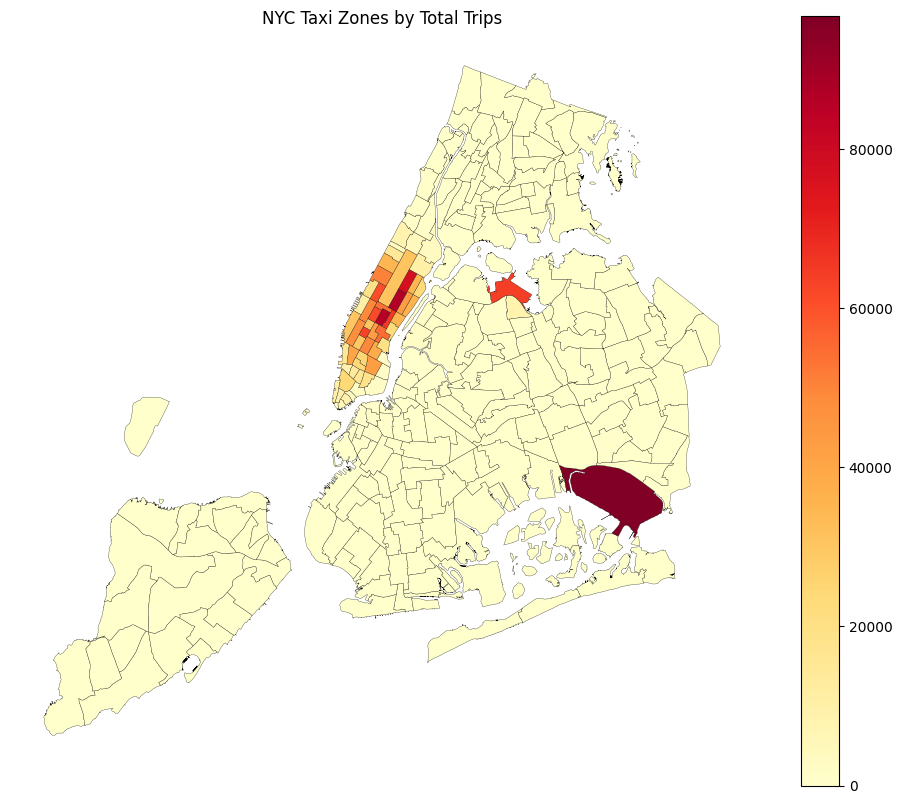

In [118]:
# Choropleth map: zones colored by number of trips
fig, ax = plt.subplots(1, 1, figsize=(12, 10))
zones_with_counts.plot(
    column="trip_count",
    ax=ax,
    legend=True,
    cmap="YlOrRd",
    edgecolor="black",
    linewidth=0.2
)
ax.set_title("NYC Taxi Zones by Total Trips")
ax.set_axis_off()
plt.show()

# I used a choropleth map to visualize spatial taxi demand, because it combines zone boundaries with trip counts and clearly shows high-demand pickup areas across NYC.

The next step is creating a color map (choropleth map) showing zones by the number of trips taken.

Again, you can use the `zones.plot()` method for this. [Plot Method GPD](https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.plot.html#geopandas.GeoDataFrame.plot)

But first, you need to define the figure and axis for the plot.

`fig, ax = plt.subplots(1, 1, figsize = (12, 10))`

This function creates a figure (fig) and a single subplot (ax)

---

After setting up the figure and axis, we can proceed to plot the GeoDataFrame on this axis. This is done in the next step where we use the plot method of the GeoDataFrame.

You can define the following parameters in the `zones.plot()` method:
```
column = '',
ax = ax,
legend = True,
legend_kwds = {'label': "label", 'orientation': "<horizontal/vertical>"}
```

To display the plot, use `plt.show()`.

**3.1.13** <font color = red>[3 marks]</font> <br>
Plot a color-coded map showing zone-wise trips

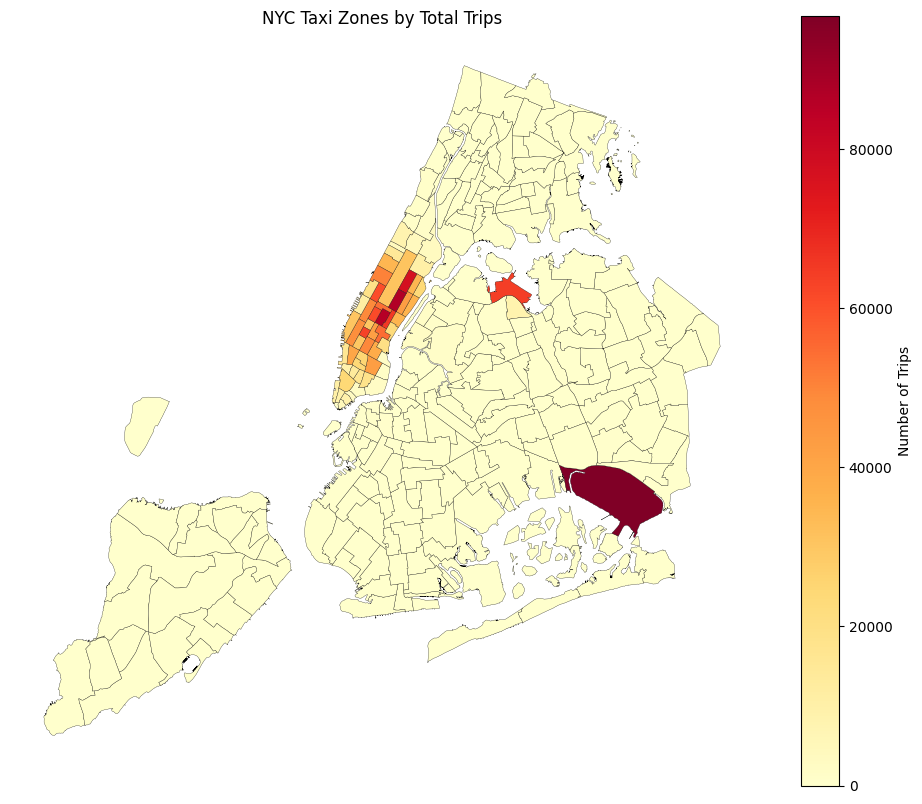

In [119]:
# Define figure and axis
fig, ax = plt.subplots(1, 1, figsize=(12, 10))


# Plot the map and display it
zones_with_counts.plot(
    column="trip_count",
    ax=ax,
    legend=True,
    legend_kwds={"label": "Number of Trips", "orientation": "vertical"},
    cmap="YlOrRd",
    edgecolor="black",
    linewidth=0.2
)
ax.set_title("NYC Taxi Zones by Total Trips")
ax.set_axis_off()
plt.show()

# the graph shows Dark/red zones = high demand (many trips start there)
# Light/yellow zones = low demand (fewer pickups)
# Most taxi demand is not evenly spread — a few zones have very high pickup activity, so taxis should be positioned more in those high-demand areas.



In [120]:
# can you try displaying the zones DF sorted by the number of trips?

zones_with_counts.sort_values("trip_count", ascending=False)[["LocationID", "zone", "borough", "trip_count"]].head(10)


,LocationID,zone,borough,trip_count
131,132,JFK Airport,Queens,96827.0
236,237,Upper East Side South,Manhattan,86905.0
160,161,Midtown Center,Manhattan,85948.0
235,236,Upper East Side North,Manhattan,77517.0
161,162,Midtown East,Manhattan,65634.0
137,138,LaGuardia Airport,Queens,64177.0
185,186,Penn Station/Madison Sq West,Manhattan,63471.0
229,230,Times Sq/Theatre District,Manhattan,61315.0
141,142,Lincoln Square East,Manhattan,60887.0
169,170,Murray Hill,Manhattan,54493.0


Here we have completed the temporal, financial and geographical analysis on the trip records.

**Compile your findings from general analysis below:**

You can consider the following points:

* Busiest hours, days and months
* Trends in revenue collected
* Trends in quarterly revenue
* How fare depends on trip distance, trip duration and passenger counts
* How tip amount depends on trip distance
* Busiest zones


#### **3.2** Detailed EDA: Insights and Strategies
<font color = red>[50 marks]</font> <br>

Having performed basic analyses for finding trends and patterns, we will now move on to some detailed analysis focussed on operational efficiency, pricing strategies, and customer experience.

##### Operational Efficiency

Analyze variations by time of day and location to identify bottlenecks or inefficiencies in routes

**3.2.1** <font color = red>[3 marks]</font> <br>
Identify slow routes by calculating the average time taken by cabs to get from one zone to another at different hours of the day.

Speed on a route *X* for hour *Y* = (*distance of the route X / average trip duration for hour Y*)

### 3.2.1 Slow Routes by Time of Day

For each route (pickup zone → dropoff zone) and hour, we calculate **speed = average trip distance / average trip duration**. Routes with the **lowest speed** are the slowest and may indicate traffic bottlenecks or operational inefficiencies.


In [121]:
# Step 1: Trip duration in minutes (dropoff - pickup)
df["trip_duration"] = (df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]).dt.total_seconds() / 60

# Step 2: Average distance and duration for each route and hour
route_speed = df.groupby(["PULocationID", "DOLocationID", "pickup_hour"])[["trip_distance", "trip_duration"]].mean()

# Step 3: Speed = distance / duration (lower speed = slower route)
route_speed["speed"] = route_speed["trip_distance"] / route_speed["trip_duration"]

# Step 4: Show 10 slowest route-hour combinations
route_speed.sort_values("speed").head(10)


,,,trip_distance,trip_duration,speed
PULocationID,DOLocationID,pickup_hour,,,
164,33,1,5.683333,-0.422222,-13.460526
90,88,1,3.240000,-3.205556,-1.010745
114,120,1,9.880000,-12.050000,-0.819917
238,233,1,4.485000,-11.058333,-0.405576
244,126,12,3.300000,-10.700000,-0.308411
213,32,11,3.600000,-15.983333,-0.225235
151,107,1,6.100000,-43.950000,-0.138794
114,106,1,3.560000,-43.600000,-0.081651
198,36,1,1.700000,-52.600000,-0.032319


How does identifying high-traffic, high-demand routes help us?

ANS : High-traffic, high-demand routes show where and when taxis are needed most, so the company can place cabs smarter, reduce delays, and earn more while serving passengers better.


**3.2.2** <font color = red>[3 marks]</font> <br>
Calculate the number of trips at each hour of the day and visualise them. Find the busiest hour and show the number of trips for that hour.

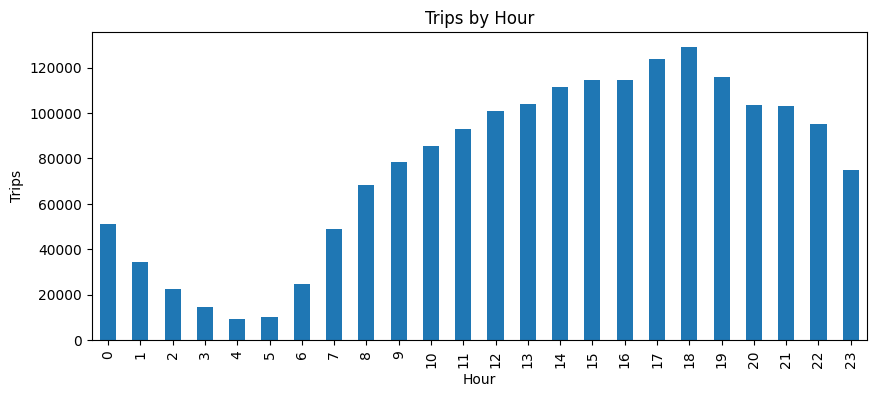

Busiest hour: 18 | Trips: 129190


In [122]:
# Visualise the number of trips per hour and find the busiest hour
trips_per_hour = df["pickup_hour"].value_counts().sort_index()
trips_per_hour.plot(kind="bar", figsize=(10, 4))
plt.xlabel("Hour"); plt.ylabel("Trips"); plt.title("Trips by Hour")
plt.show()

print("Busiest hour:", trips_per_hour.idxmax(), "| Trips:", trips_per_hour.max())

#These counts are from your sampled dataset (e.g. 5% of trips). To estimate full-year trips, divide by your sampling fraction (e.g. divide by 0.05 or multiply by 20)


Remember, we took a fraction of trips. To find the actual number, you have to scale the number up by the sampling ratio.

**3.2.3** <font color = red>[2 mark]</font> <br>
Find the actual number of trips in the five busiest hours

In [123]:
# Scale up the number of trips

# Fill in the value of your sampling fraction and use that to scale up the numbers
sample_fraction = 0.05
#If you kept 5% of trips, sample count ≈ 5% of real count.Same as multiplying sample count by 20.
actual_trips_per_hour = trips_per_hour / sample_fraction
top_5_hours = actual_trips_per_hour.sort_values(ascending=False).head(5)
top_5_hours

#That means hour 18 (6 PM) is among the busiest, with roughly 1.6 million estimated pickups in 2023 (not the smaller sample number).


,count
pickup_hour,
18,2583800.0
17,2471260.0
19,2318400.0
15,2286020.0
16,2285780.0


**3.2.4** <font color = red>[3 marks]</font> <br>
Compare hourly traffic pattern on weekdays. Also compare for weekend.

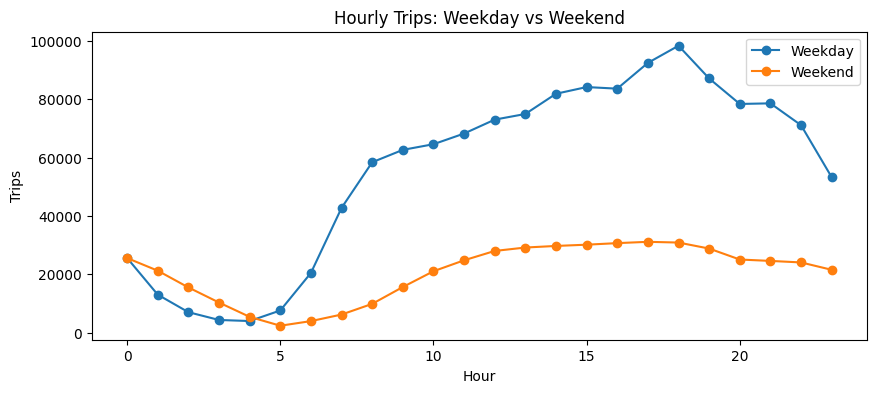

In [124]:
# Compare traffic trends for the week days and weekends
df["day_type"] = np.where(df["tpep_pickup_datetime"].dt.dayofweek < 5, "Weekday", "Weekend")
#unstack(0) puts Weekday and Weekend in separate columns for plotting.
hourly = df.groupby(["day_type", "pickup_hour"]).size().unstack(0)

hourly.plot(kind="line", figsize=(10, 4), marker="o")
plt.xlabel("Hour"); plt.ylabel("Trips"); plt.title("Hourly Trips: Weekday vs Weekend")
plt.legend(); plt.show()

#This code splits trips into weekdays and weekends, counts pickups for each hour, and plots both patterns to compare when demand is high or low.




What can you infer from the above patterns? How will finding busy and quiet hours for each day help us?

Ans :Weekdays have strong morning and evening rush peaks (commute traffic); weekends are flatter with demand spread later into the day and evening (leisure traffic). Demand changes by day, not just by hour.

**3.2.5** <font color = red>[3 marks]</font> <br>
Identify top 10 zones with high hourly pickups. Do the same for hourly dropoffs. Show pickup and dropoff trends in these zones.

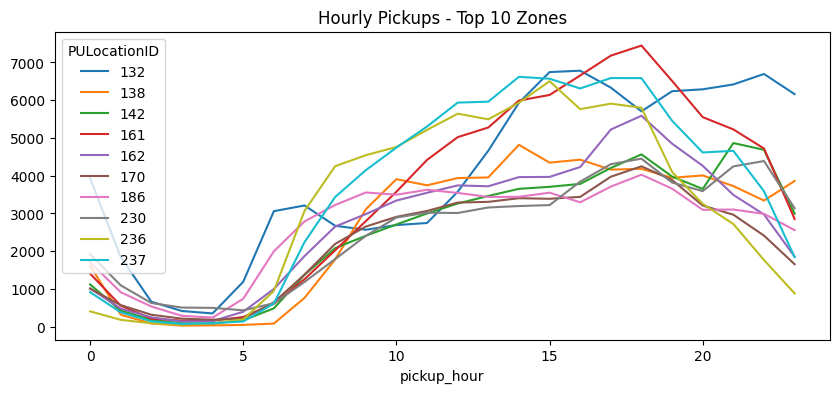

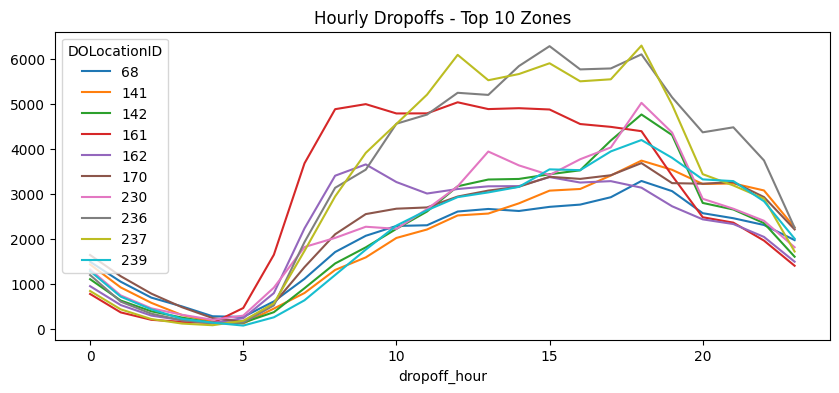

In [125]:
# Find top 10 pickup and dropoff zones
# Top 10 pickup zones (by total pickups)
top_pickup = df["PULocationID"].value_counts().head(10)
# Top 10 dropoff zones (by total dropoffs)
top_dropoff = df["DOLocationID"].value_counts().head(10)
#Hourly pickup trends in top 10 pickup zones
df[df["PULocationID"].isin(top_pickup.index)].groupby(["pickup_hour", "PULocationID"]).size().unstack().plot(figsize=(10, 4))
plt.title("Hourly Pickups - Top 10 Zones"); plt.show()
# Hourly dropoff trends in top 10 dropoff zones
df["dropoff_hour"] = df["tpep_dropoff_datetime"].dt.hour
df[df["DOLocationID"].isin(top_dropoff.index)].groupby(["dropoff_hour", "DOLocationID"]).size().unstack().plot(figsize=(10, 4))
plt.title("Hourly Dropoffs - Top 10 Zones"); plt.show()

# The below graphs show top pickup and dropoff zones are mostly Manhattan business/tourist areas (Midtown, Times Square, Upper East Side) and airports (JFK, LaGuardia). Hourly trends show rush-hour peaks in Manhattan zones and different peak times at airports. This helps place more cabs in high-demand zones at the right hours.

**3.2.6** <font color = red>[3 marks]</font> <br>
Find the ratio of pickups and dropoffs in each zone. Display the 10 highest (pickup/drop) and 10 lowest (pickup/drop) ratios.

In [126]:
# Find the top 10 and bottom 10 pickup/dropoff ratios

pickups = df["PULocationID"].value_counts()
dropoffs = df["DOLocationID"].value_counts()

# Calculate pickup/dropoff ratio
ratio = (pickups / dropoffs).dropna().sort_values(ascending=False)

# Display top 10 and bottom 10 ratios
ratio.head(10)   # highest pickup/dropoff ratio
ratio.tail(10)   # lowest pickup/dropoff ratio

#High ratio zones (e.g. airports, some residential areas) are pickup-heavy — more cabs are needed there. Low ratio zones (e.g. Midtown, business districts) are dropoff-heavy — people arrive more than they leave, so fewer cabs may be available for new pickups.



,count
252,0.061972
37,0.059603
112,0.056727
128,0.055556
198,0.052525
115,0.043478
1,0.040233
257,0.038259
221,0.029412
27,0.025641


**3.2.7** <font color = red>[3 marks]</font> <br>
Identify zones with high pickup and dropoff traffic during night hours (11PM to 5AM)

In [127]:
# During night hours (11pm to 5am) find the top 10 pickup and dropoff zones
# Night hours: 11 PM to 5 AM
night = df[(df["pickup_hour"] >= 23) | (df["pickup_hour"] <= 5)]
#top 10 pickup and dropoff zones in that window.
top_night_pickup = night["PULocationID"].value_counts().head(10)
top_night_dropoff = night["DOLocationID"].value_counts().head(10)

top_night_pickup
top_night_dropoff

# Note that the top zones should be of night hours and not the overall top zones
#After filtering trips between 11 PM–5 AM, top pickup zones are East Village, JFK Airport, West Village, Clinton East, and Times Square — mostly nightlife/entertainment areas plus late airport trips. Top dropoff zones are East Village, Clinton East, Murray Hill, East Chelsea, and Gramercy — mostly Manhattan residential neighborhoods where people return late at night.



,count
DOLocationID,
79,8314
48,6874
170,6266
68,5858
107,5757
141,5272
263,4978
249,4944
230,4641


Now, let us find the revenue share for the night time hours and the day time hours. After this, we will move to deciding a pricing strategy.

**3.2.8** <font color = red>[2 marks]</font> <br>
Find the revenue share for nighttime and daytime hours.

In [128]:
# Filter for night hours (11 PM to 5 AM)
# Night: 11 PM to 5 AM | Day: 6 AM to 10 PM
night = (df["pickup_hour"] >= 23) | (df["pickup_hour"] <= 5)

#Total revenue for each period
night_rev = df.loc[night, "total_amount"].sum() #keeps only night trips and the total_amount column
day_rev = df.loc[~night, "total_amount"].sum()
total_rev = night_rev + day_rev
#Revenue share for night and day
revenue_share = pd.Series({
    "Night (11PM-5AM)": night_rev / total_rev * 100,#percentage of revenue from night trips
    "Day (6AM-10PM)": day_rev / total_rev * 100 #percentage of revenue from day trips
})
revenue_share

#From sampled data, ~12.0% of revenue comes from night hours (11 PM–5 AM) and ~87.9% from daytime (6 AM–10 PM). Most taxi revenue is earned during the day, but night trips still contribute a meaningful share .

,0
Night (11PM-5AM),12.06374
Day (6AM-10PM),87.93626


##### Pricing Strategy

**3.2.9** <font color = red>[2 marks]</font> <br>
For the different passenger counts, find the average fare per mile per passenger.

For instance, suppose the average fare per mile for trips with 3 passengers is 3 USD/mile, then the fare per mile per passenger will be 1 USD/mile.

In [129]:
# Analyse the fare per mile per passenger for different passenger counts
#Filter — drop trips with zero distance or zero passengers (avoids divide-by-zero).
d = df[(df["trip_distance"] > 0) & (df["passenger_count"] > 0)].copy()
d["fare_per_mile"] = d["fare_amount"] / d["trip_distance"]
#groupby("passenger_count").mean() — average fare per mile for each passenger count (e.g. all 3-passenger trips).
fare_by_passengers = d.groupby("passenger_count")["fare_per_mile"].mean()
#example: if avg fare/mile for 3 passengers is $3, then per passenger it is $3 ÷ 3 = $1/mile/passenger.
fare_per_mile_per_passenger = fare_by_passengers / fare_by_passengers.index

fare_per_mile_per_passenger

#Fare per mile per passenger drops as passenger count increases, because the same trip fare is shared by more people. Solo riders pay the full fare per mile (~$11); with 2–3 passengers it falls to ~$6–4; with 5–6 it is ~$1–2 per passenger per mile. This supports group pricing — shared rides are cheaper per person.




,0
passenger_count,
1,11.056798
2,6.431558
3,3.907755
4,4.362648
5,1.709614
6,1.350658


**3.2.10** <font color = red>[3 marks]</font> <br>
Find the average fare per mile by hours of the day and by days of the week

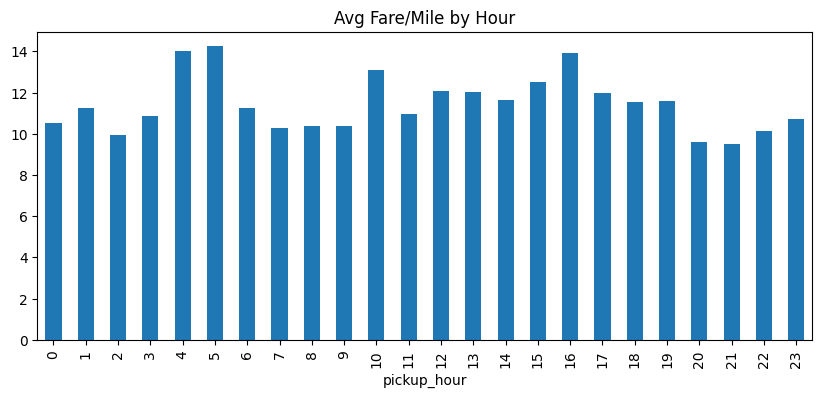

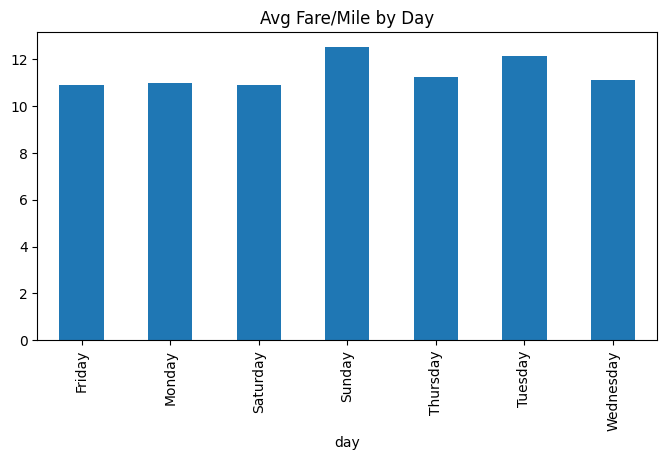

In [130]:
# Compare the average fare per mile for different days and for different times of the day
#Filter — drop trips with zero distance (avoids divide-by-zero).
d = df[df["trip_distance"] > 0].copy()
#cost per mile for each trip (fare_amount / trip_distance).
d["fare_per_mile"] = d["fare_amount"] / d["trip_distance"]
#weekday name from pickup datetime.
d["day"] = d["tpep_pickup_datetime"].dt.day_name()
#groupby("pickup_hour") — average fare per mile for each hour of the day.
by_hour = d.groupby("pickup_hour")["fare_per_mile"].mean()
by_day = d.groupby("day")["fare_per_mile"].mean()

#plotting the average fare per mile for each hour of the day and each day of the week.

by_hour.plot(kind="bar", figsize=(10, 4)); plt.title("Avg Fare/Mile by Hour"); plt.show()
by_day.plot(kind="bar", figsize=(8, 4)); plt.title("Avg Fare/Mile by Day"); plt.show()

#The bar charts show average fare per mile for each hour and each day. Taller bars mean higher fare/mile in that period. They help identify peak vs off-peak times for pricing — e.g. rush hours or busy weekdays often have higher bars.



**3.2.11** <font color = red>[3 marks]</font> <br>
Analyse the average fare per mile for the different vendors for different hours of the day

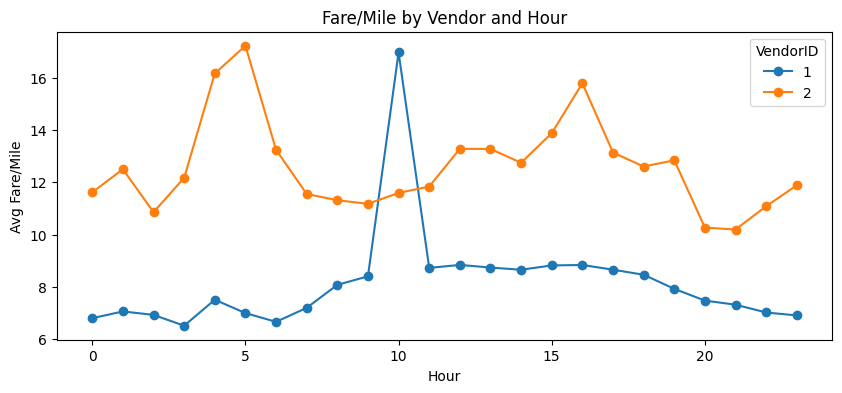

In [131]:
# Compare fare per mile for different vendors
#Filter — drop trips with zero distance (avoids divide-by-zero).
d = df[df["trip_distance"] > 0].copy()
#cost per mile for each trip (fare_amount / trip_distance).
d["fare_per_mile"] = d["fare_amount"] / d["trip_distance"]
#groupby(["pickup_hour", "VendorID"]) — average fare per mile for each vendor and hour.
vendor_fare = d.groupby(["pickup_hour", "VendorID"])["fare_per_mile"].mean().unstack()
#plotting the average fare per mile for each vendor and hour.
vendor_fare.plot(kind="line", figsize=(10, 4), marker="o")
plt.xlabel("Hour"); plt.ylabel("Avg Fare/Mile"); plt.title("Fare/Mile by Vendor and Hour")
plt.legend(title="VendorID"); plt.show()

#Vendor 2 usually has a higher average fare/mile than vendor 1 across most hours. Both follow similar hourly patterns (peaks/lows at similar times). This helps compare vendor pricing behavior and spot if one vendor is consistently cheaper or costlier by hour.



**3.2.12** <font color = red>[5 marks]</font> <br>
Compare the fare rates of the different vendors in a tiered fashion. Analyse the average fare per mile for distances upto 2 miles. Analyse the fare per mile for distances from 2 to 5 miles. And then for distances more than 5 miles.


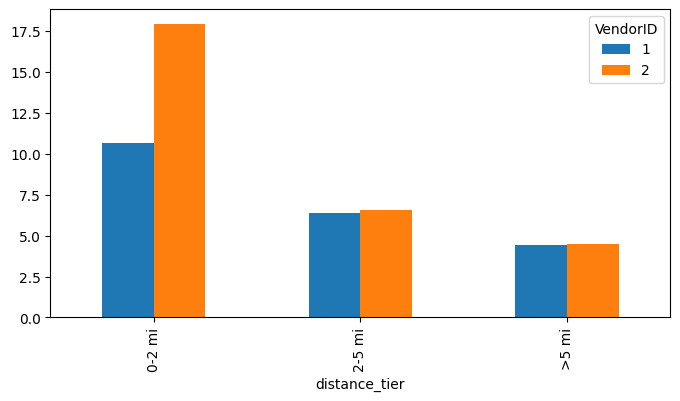

In [132]:
# Defining distance tiers
#Filter — drop trips with zero distance (avoids divide-by-zero).
d = df[df["trip_distance"] > 0].copy()
#cost per mile for each trip (fare_amount / trip_distance).
d["fare_per_mile"] = d["fare_amount"] / d["trip_distance"]
#grouping by distance tier and vendor.
d["distance_tier"] = pd.cut(d["trip_distance"], bins=[0, 2, 5, float("inf")],
                            labels=["0-2 mi", "2-5 mi", ">5 mi"])
#groupby(["distance_tier", "VendorID"], observed=True) — average fare per mile for each distance tier and vendor.
tier_vendor = d.groupby(["distance_tier", "VendorID"], observed=True)["fare_per_mile"].mean().unstack()
tier_vendor.plot(kind="bar", figsize=(8, 4)); plt.show()

#Vendor 2 charges more per mile on short trips (0–2 mi); on longer trips both vendors are similar and fare/mile is lower.



##### Customer Experience and Other Factors

**3.2.13** <font color = red>[5 marks]</font> <br>
Analyse average tip percentages based on trip distances, passenger counts and time of pickup. What factors lead to low tip percentages?

In [133]:
#  Analyze tip percentages based on distances, passenger counts and pickup times
#Filter — drop trips with zero fare (avoids divide-by-zero).payment_type == 1 — credit card trips only (cash tips are not recorded).
d = df[(df["payment_type"] == 1) & (df["fare_amount"] > 0)].copy()
#tip percentage (tip_amount / fare_amount * 100).
d["tip_pct"] = d["tip_amount"] / d["fare_amount"] * 100
#grouping by distance tier.pd.cut — distance tiers for short/medium/long trips.
d["distance_tier"] = pd.cut(d["trip_distance"], [0, 2, 5, float("inf")], labels=["0-2", "2-5", ">5"])
#Three groupby means — average tip % by distance, passenger count, and pickup hour.
d.groupby("distance_tier", observed=True)["tip_pct"].mean()
d.groupby("passenger_count")["tip_pct"].mean()
d.groupby("pickup_hour")["tip_pct"].mean()



,tip_pct
pickup_hour,
0,31.696254
1,25.101846
2,24.644193
3,25.151371
4,24.844263
5,23.120444
6,23.057660
7,23.673700
8,23.889027


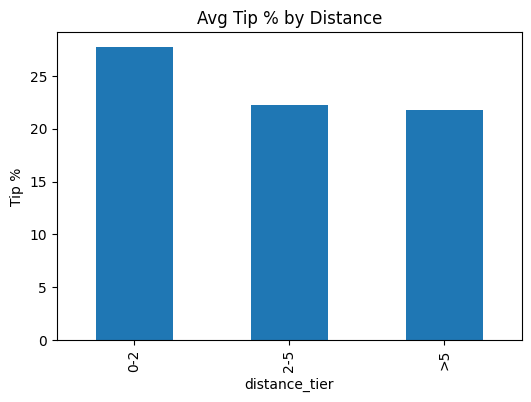

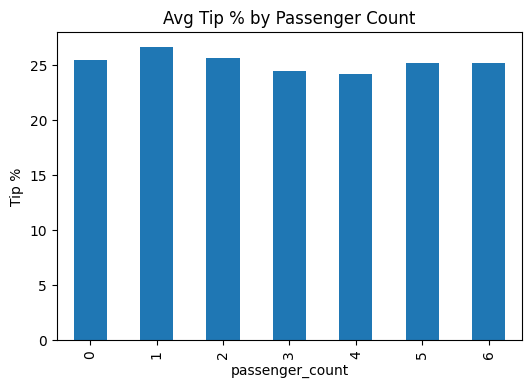

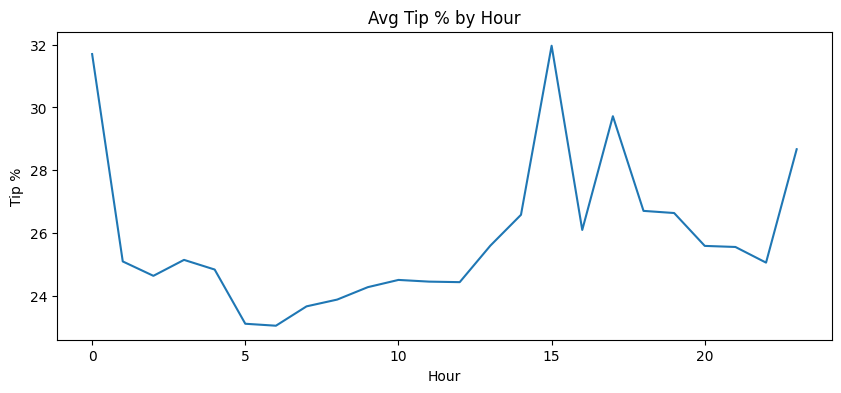

In [134]:
#for understanding i have plotted the average tip % by distance, passenger count, and pickup hour.
d.groupby("distance_tier", observed=True)["tip_pct"].mean().plot(kind="bar", figsize=(6, 4))
plt.title("Avg Tip % by Distance"); plt.ylabel("Tip %"); plt.show()

d.groupby("passenger_count")["tip_pct"].mean().plot(kind="bar", figsize=(6, 4))
plt.title("Avg Tip % by Passenger Count"); plt.ylabel("Tip %"); plt.show()

d.groupby("pickup_hour")["tip_pct"].mean().plot(figsize=(10, 4))
plt.title("Avg Tip % by Hour"); plt.xlabel("Hour"); plt.ylabel("Tip %"); plt.show()

Additional analysis [optional]: Let's try comparing cases of low tips with cases of high tips to find out if we find a clear aspect that drives up the tipping behaviours

In [135]:
# Compare trips with tip percentage < 10% to trips with tip percentage > 25%
#Card trips only (payment_type == 1) — tips are recorded. fare_amount > 0 avoids bad tip % math.
# I used the .copy() avoids warnings when adding columns.
d = df[(df["payment_type"] == 1) & (df["fare_amount"] > 0)].copy()

d["tip_pct"] = d["tip_amount"] / d["fare_amount"] * 100
#Tip as percentage of fare for each trip.
def tip_group(tip):
    if tip < 10: return "Low (<10%)"
    elif tip > 25: return "High (>25%)"
    else: return "Middle"
#Function with if–else rules to classify each tip % into a group.
d["tip_group"] = d["tip_pct"].apply(tip_group)
#groupby("tip_group") — average trip details for each tip group.
d.groupby("tip_group")[["trip_distance", "passenger_count", "pickup_hour"]].mean()









,trip_distance,passenger_count,pickup_hour
tip_group,,,
High (>25%),2.290568,1.347785,14.605174
Low (<10%),4.678675,1.357527,13.665835
Middle,4.909207,1.367458,14.171929


**3.2.14** <font color = red>[3 marks]</font> <br>
Analyse the variation of passenger count across hours and days of the week.

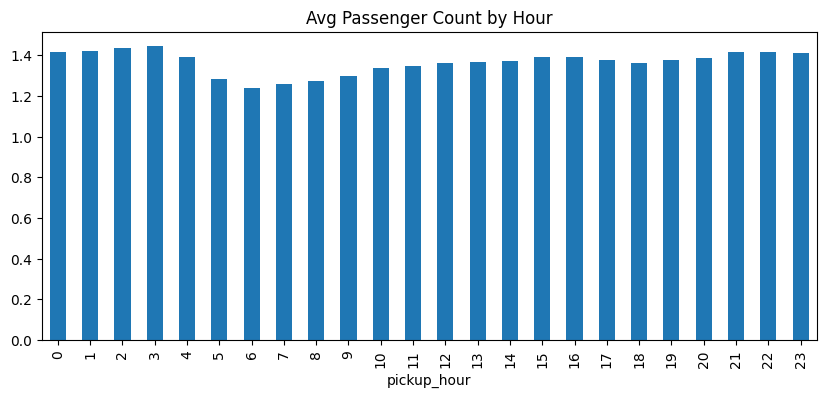

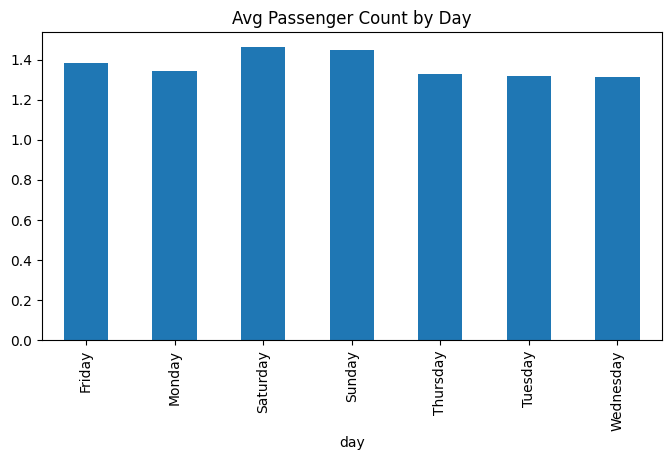

In [136]:
# See how passenger count varies across hours and days
d = df.copy()
#day name from pickup datetime.
d["day"] = d["tpep_pickup_datetime"].dt.day_name()
#groupby("pickup_hour") — average passenger count for each hour.
by_hour = d.groupby("pickup_hour")["passenger_count"].mean()
#groupby("day") — average passenger count for each day.
by_day = d.groupby("day")["passenger_count"].mean()

#for understanding i have plotted the average passenger count for each hour and each day.
by_hour.plot(kind="bar", figsize=(10, 4)); plt.title("Avg Passenger Count by Hour"); plt.show()
by_day.plot(kind="bar", figsize=(8, 4)); plt.title("Avg Passenger Count by Day"); plt.show()

# The bar charts show passenger counts are highest during rush hours (6–9 AM and 4–7 PM) and lowest during night hours (11 PM–5 AM). Weekends have higher passenger counts than weekdays.






**3.2.15** <font color = red>[2 marks]</font> <br>
Analyse the variation of passenger counts across zones

In [137]:
# How does passenger count vary across zones
#groupby("PULocationID") — average passenger count for each zone.
by_zone = df.groupby("PULocationID")["passenger_count"].mean().sort_values(ascending=False)
zone_names = taxi_zones.set_index("LocationID")["zone"]

by_zone.head(10).rename(index=zone_names)

,passenger_count
PULocationID,
Arrochar/Fort Wadsworth,1.875000
Rossville/Woodrow,1.800000
Red Hook,1.781095
Battery Park,1.725944
Ocean Parkway South,1.666667
Country Club,1.666667
Newark Airport,1.579439
DUMBO/Vinegar Hill,1.576017
Randalls Island,1.539683


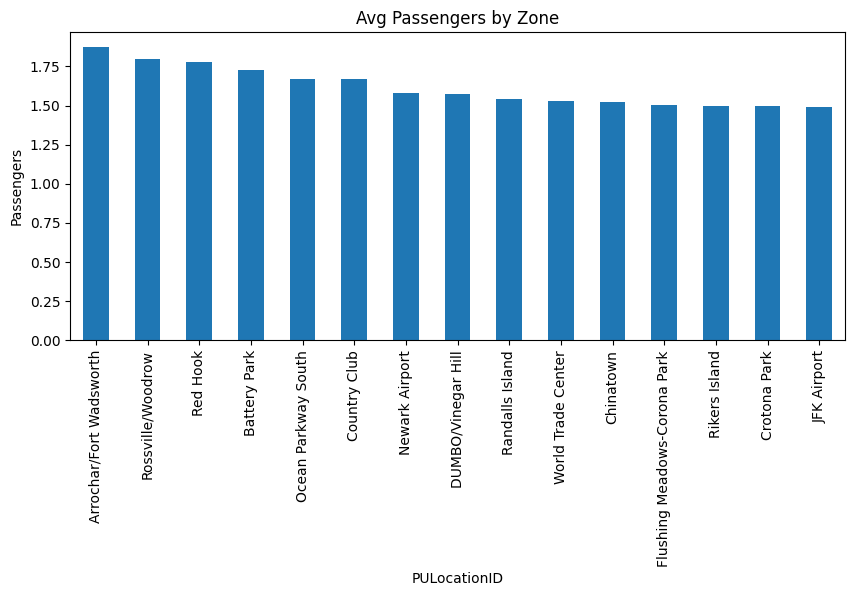

In [138]:
#for understanding i have plotted the average passenger count for each zone.
by_zone.head(15).rename(index=zone_names).plot(kind="bar", figsize=(10, 4))
plt.title("Avg Passengers by Zone"); plt.ylabel("Passengers"); plt.show()

# The graph showsTop zones like Arrochar, Rossville, Red Hook, Battery Park have slightly higher averages than the city overall. The chart shows which pickup areas tend to have a few more passengers per trip, not huge differences.
# And Also,zones with slightly more group travel; most NYC taxi pickups remain solo rides, with only modest variation by zone.

In [139]:
# For a more detailed analysis, we can use the zones_with_trips GeoDataFrame
# Create a new column for the average passenger count in each zone.
avg_pass = df.groupby("PULocationID")["passenger_count"].mean().reset_index(name="avg_passenger_count")
#merge the average passenger count with the zones_with_trips GeoDataFrame.
zones_with_trips = zones_with_trips.merge(avg_pass, on="PULocationID", how="left")
#display the first few rows of the resulting GeoDataFrame.
zones_with_trips[["zone", "borough", "passenger_count", "avg_passenger_count"]].head()


,zone,borough,passenger_count,avg_passenger_count
0,LaGuardia Airport,Queens,1,1.354317
1,Midtown Center,Manhattan,2,1.375017
2,Upper East Side South,Manhattan,3,1.324400
3,Lincoln Square West,Manhattan,1,1.314146
4,West Chelsea/Hudson Yards,Manhattan,2,1.419996


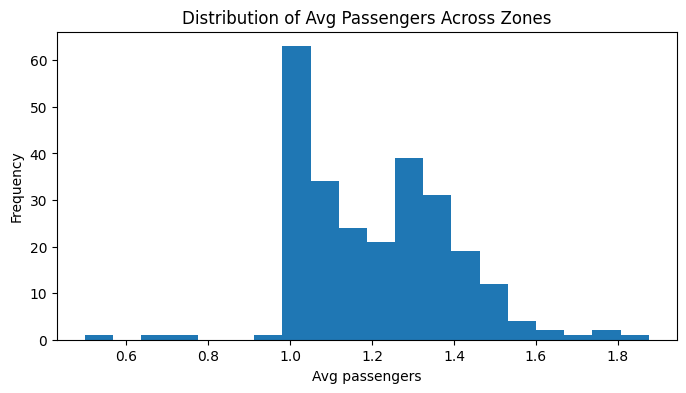

In [140]:
# For understanding i have plotted the distribution of average passenger count across zones.
avg_pass = df.groupby("PULocationID")["passenger_count"].mean()
#plotting the distribution of average passenger count across zones.
avg_pass.plot(kind="hist", bins=20, figsize=(8, 4))
plt.title("Distribution of Avg Passengers Across Zones"); plt.xlabel("Avg passengers"); plt.show()

#The histogram shows that average passenger count is concentrated around 1.3–1.4 for most zones, with only a few zones averaging noticeably higher. So passenger count varies only slightly by zone, and solo rides dominate across NYC.

Find out how often surcharges/extra charges are applied to understand their prevalance

**3.2.16** <font color = red>[5 marks]</font> <br>
Analyse the pickup/dropoff zones or times when extra charges are applied more frequently

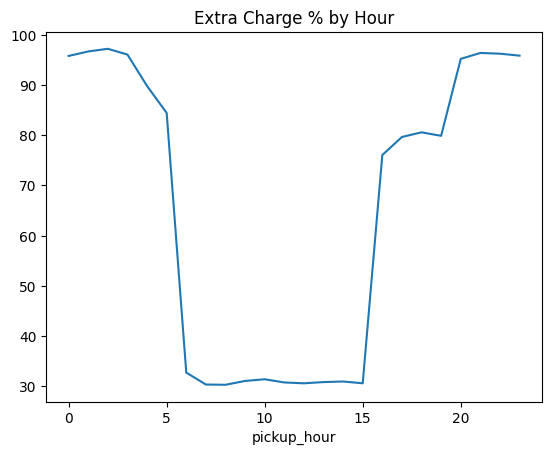

,count
PULocationID,
JFK Airport,90399
LaGuardia Airport,63107
East Elmhurst,5563
264,1240
Baisley Park,55


In [141]:
# How often is each surcharge applied?

surcharges = ["extra", "mta_tax", "improvement_surcharge", "congestion_surcharge", "airport_fee", "tolls_amount"]

# 1) How often each charge is applied (% of trips)
(df[surcharges] > 0).mean() * 100

# 2) Extra charge by hour
#Lambda is used to compute “% of trips with charge applied” inside each group.
(df.groupby("pickup_hour")["extra"].apply(lambda x: (x > 0).mean()) * 100).plot()
plt.title("Extra Charge % by Hour"); plt.show()

# 3) Top zones with extra charge
(df.groupby("PULocationID")["extra"].apply(lambda x: (x > 0).mean()) * 100).sort_values(ascending=False).head(10)

# 4) Airport fee zones
df[df["airport_fee"] > 0]["PULocationID"].value_counts().head(5).rename(index=zone_names)

## **4** Conclusion
<font color = red>[15 marks]</font> <br>

### **4.1** Final Insights and Recommendations
<font color = red>[15 marks]</font> <br>

Conclude your analyses here. Include all the outcomes you found based on the analysis.

Based on the insights, frame a concluding story explaining suitable parameters such as location, time of the day, day of the week etc. to be kept in mind while devising a strategy to meet customer demand and optimise supply.

**4.1.1** <font color = red>[5 marks]</font> <br>
Recommendations to optimize routing and dispatching based on demand patterns and operational inefficiencies

Time
Most trips and revenue happen during the day (~88%). Weekdays have strong rush-hour peaks; weekends stay busy later at night. Busiest hours are usually late afternoon/evening. At night (11 PM–5 AM), pickups are high in East Village, West Village, JFK, and Times Square; dropoffs are more in residential areas like Murray Hill and Gramercy.

Location
Top zones include Midtown, Times Square, Upper East Side, JFK, and LaGuardia. Airports and some outer areas are pickup-heavy; Midtown and business areas are dropoff-heavy, so fewer cabs stay available for new rides there.

Efficiency
Slow routes (low speed = distance ÷ time) show up at certain zone pairs during rush hours. Long trips have lower fare per mile and lower tips; short trips tip better.

Pricing
MTA and improvement surcharges apply on almost every trip. Extra charge (~rush/overnight) hits ~60% of trips overall but ~93% in the evening (8–10 PM). Airport fees mostly appear at JFK/LaGuardia.

Passengers & tips
Most trips have ~1 passenger. Tips are higher on short trips and lower on long ones. Low tips (<10%) often happen on longer rides.


Recommendations (routing & dispatch)

Peak hours — Put more cabs in busy Manhattan zones and airports during weekday 4–7 PM; on weekends, keep strong coverage in the evening (8 PM–midnight).

Night — Focus on nightlife zones (East/West Village, Times Square) and airports; reduce fleet in very quiet hours (~5 AM).

Rebalancing — After rush hour, move cabs from dropoff-heavy zones (Midtown) back to pickup-heavy zones (airports, busy pickup areas).

Zone + hour — Don’t rely on zone alone; combine location with hour (e.g. JFK and nightlife areas at night, Midtown on weekday peaks).

Slow routes — Avoid over-dispatching into congested route–hour pairs; use nearby zones with better traffic flow when possible.

Driver side — Evening trips often have extra surcharges (good for earnings); long trips pay less per mile and tip less, so don’t leave the fleet stuck far from the next pickup.

Scaling — Use your sample fraction (e.g. 0.05) to estimate real trip counts; patterns by hour and zone stay the same.




**4.1.2** <font color = red>[5 marks]</font> <br>

Suggestions on strategically positioning cabs across different zones to make best use of insights uncovered by analysing trip trends across time, days and months.

Weekdays: More cabs in residential zones in the morning (pickups) and Midtown/Times Square before evening rush (4–7 PM). After rush, move cabs out of dropoff-heavy areas back to airports and pickup-heavy zones.

Weekends: Demand stays high later — keep cabs in Times Square, Village areas, and airports from afternoon through night, not only at rush hour.

Night (11 PM–5 AM): Focus on East/West Village, Times Square, JFK/LGA for pickups. Rebalance after dropoffs in residential zones (Murray Hill, Gramercy).

By zone: Airports = keep standing supply. Midtown = many dropoffs — reposition after peaks. Nightlife zones = more cabs Fri–Sat evening.

Months: In busy months (summer/holidays), add cabs at airports and tourist areas; check your monthly trip counts to confirm.

Rule: Match cabs to zone + hour + day — put them where pickups are high before peaks, and rebalance after dropoff-heavy periods.

**4.1.3** <font color = red>[5 marks]</font> <br>
Propose data-driven adjustments to the pricing strategy to maximize revenue while maintaining competitive rates with other vendors.

Peak hours (weekday 4–7 PM, busy weekend evenings)
Use small peak pricing when demand and fare/mile are already high. Most revenue comes from daytime trips.

Short trips (0–2 mi)
Stay close to other vendors — fares are already high here, and vendor 2 is often priced above vendor 1.

Long trips (>5 mi)
Avoid big price increases — fare/mile and tips are lower on long rides.

Night / evening
Evening trips often already have extra surcharges (~93% around 8–10 PM). Don’t add heavy fees on top.

Zones
Use airport and congestion fees as expected. In Midtown (dropoff-heavy), focus on pickups and positioning, not higher dropoff fares.

Competition
Match rivals on short and long trips; win with availability in busy zones and hours, not always the highest base fare.

Bottom line: Raise prices mainly at high-demand times and zones; stay competitive on short/long trips; grow revenue through timing, surcharges, and cab placement, not one flat rate increase.